# Setup

## Imports & Setup

In [1]:
import jax
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt
import matplotlib

jax.config.update("jax_enable_x64", True)

In [2]:
print(plt.rcParams["font.sans-serif"])
print(plt.rcParams["font.monospace"])

['DejaVu Sans', 'Bitstream Vera Sans', 'Computer Modern Sans Serif', 'Lucida Grande', 'Verdana', 'Geneva', 'Lucid', 'Arial', 'Helvetica', 'Avant Garde', 'sans-serif']
['DejaVu Sans Mono', 'Bitstream Vera Sans Mono', 'Computer Modern Typewriter', 'Andale Mono', 'Nimbus Mono L', 'Courier New', 'Courier', 'Fixed', 'Terminal', 'monospace']


In [3]:
# fancy figures

plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["font.sans-serif"] = ["Lucida Grande"]

#plt.rc('font', size=15) 


axline = {'c':'k', 'ls':'--', 'lw':1}

fig_path = "/Users/skowalski/Desktop/figures/"

## Important Parameters

In [4]:
T = 300  #K
mu = 0.3 # eV

kB = 8.617E-5 # eV/K
beta = 1/(kB * T)

beta = 40

N1 = N2 = int( 40. * np.log(beta) )

sqrt_beta = np.sqrt(beta)

N1, N2

(147, 147)

## Learnable Functions

In [5]:
# Iterations
N = 30

cutoff = 15

In [6]:
def cubic_fun(x,w):
    a = w
    return x * (1 + a * x * x), None

def quad_fun(x,w):
    a,b,c,d = w
    y = a + b * x + c * x * x
    return y, d * y

def cubic(X, W):
    return jax.lax.scan(cubic_fun, X, W)[0]

def quad(X, W):
    return jnp.sum( jax.lax.scan(quad_fun, X, W)[1], axis = 0 )

def reshape_W(W):
    return jnp.asarray(W, dtype=jnp.float64).reshape(len(W)//4, 4)

## SP2 Implementation

In [7]:
# generate µ[i] and generalized quadratic weights equivalent to SP2 algorithm
# via Kipton's recursive relation

def SP2_weights(N, mu):

    mus = [1/2]
    W_SP2 = np.zeros((N,4))

    for n in range(N):
        yi = 1/2
        
        for i in range(n, -1, -1):

            if mus[i] < mu:
                yi = np.sqrt(yi)
            else:
                yi = 1 - np.sqrt(1 - yi)

        mus.append(yi)

        if mus[n] < mu:
            W_SP2[n] = 0, 0, 1, 0
        else:
            W_SP2[n] = 0, 2, -1, 0

    W_SP2[-1,-1] = 1

    return W_SP2, mus

# Josh's Version
def SP2_weights(N, mu):

    mus = [mu]
    W_SP2 = np.zeros((N,4))

    for n in range(N):

        m = mus[-1]

        if jnp.abs(m**2 - mu) < jnp.abs(2*m - m**2 - mu):
            mus.append(m**2)
            W_SP2[n] = 0, 0, 1, 0
        else:
            mus.append(2*m - m**2)
            W_SP2[n] = 0, 2, -1, 0

    W_SP2[-1,-1] = 1

    return W_SP2, mus

W_SP2, mus = SP2_weights(N, mu)

In [ ]:
# check if mus are computed correctly
print(*[f'{quad(mus[i], jnp.array(W_SP2)[:i].at[-1,-1].set(1)):.3f}' for i in range(1,N+1)])

## $\mu$ and error convergence

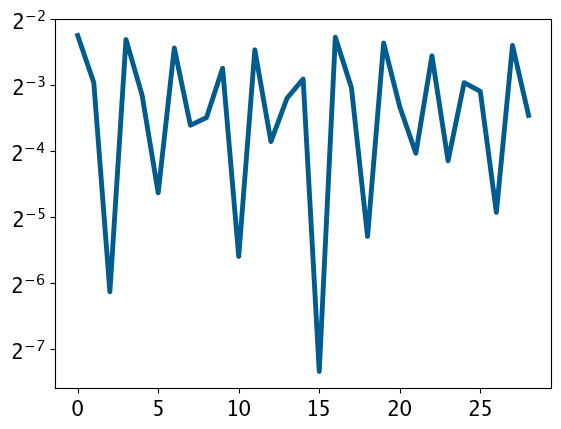

In [ ]:
mu_i = [ SP2_weights(i,mu)[1][-1] for i in range(1,N) ]

plt.plot(jnp.abs(jnp.array(mu_i) - mu), label='error')
plt.yscale('log', base=2)

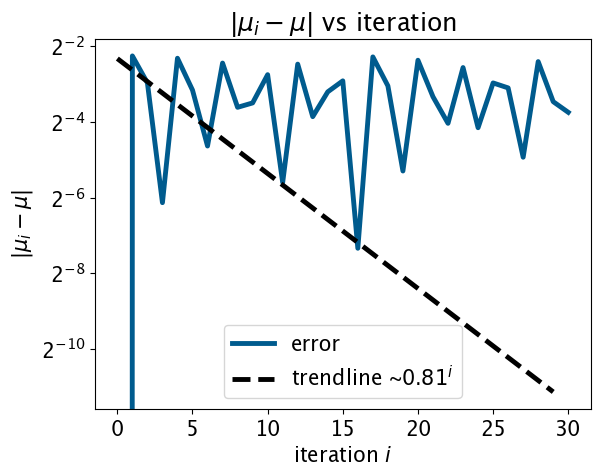

In [ ]:

plt.plot(jnp.abs(jnp.array(mus) - mu), label='error')
plt.plot(0.2 * 0.81 ** jnp.arange(30), 'k--', label='trendline ~$0.81^i$')
plt.yscale('log', base=2)

plt.title(r'$|\mu_i - \mu|$ vs iteration')
plt.ylabel(r'$|\mu_i - \mu|$')
plt.xlabel(r'iteration $i$')
plt.legend()

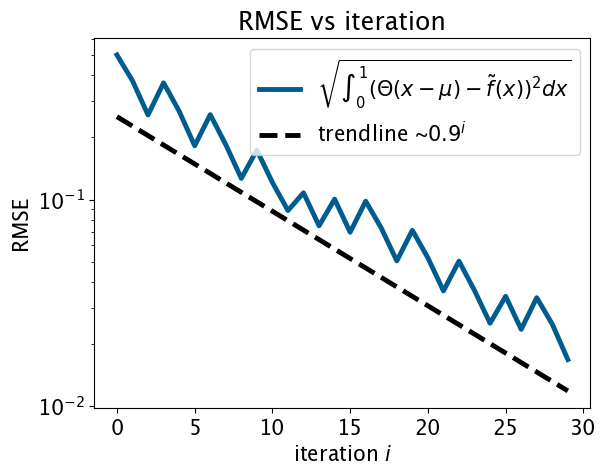

In [ ]:
x = jnp.linspace(0,1,1000)
y = jnp.where(x>mu, 1, 0)

def rmse(x):
    return jnp.sqrt( jnp.mean( x**2 ) )

RMSEs = [ rmse(quad(x, jnp.array(W_SP2)[:i].at[-1,-1].set(1)) - y ) for i in range(1,N+1)]

plt.semilogy( RMSEs, label=r'$\sqrt{\int_0^1 (\Theta(x-\mu) - \tilde f(x))^2 dx}$' )
plt.semilogy([0.28*0.9**i for i in range(1,N+1)], 'k--', label='trendline ~$0.9^i$')

plt.title('RMSE vs iteration')
plt.ylabel('RMSE')
plt.xlabel(r'iteration $i$')
plt.legend()

## Define NN Models

In [ ]:
# setup models

std  = 1.13/np.sqrt(2*beta)
key = jax.random.key(1)

def sample_dist(key, N1=N1, N2=N2):
    key, subkey = jax.random.split(key)
    X = jnp.concat((
            jax.random.normal(key, (N1,)) * std + mu,
            jax.random.uniform(subkey, (N2,))
        ))
    X = jnp.clip(X, 0, 1)
    return X, key

def target(X, beta=beta, mu=mu):
    return 0.5 * ( 1 + jnp.tanh(beta * (X - mu)) )

In [ ]:
sq = lambda x: x @ x

def mlsp2j(X, W, Y=0):
    I = jnp.eye(X.shape[0])
    Y = Y * I
    for a,b,c,d in W:
        Y += d * X
        X  = a * (X @ X) + b * X + c * I
    return I - (Y + X)

def mlsp2j_trunc(X, W, Y=0):
    I = jnp.eye(X.shape[0])
    Y = Y * I
    for a,b,c,d in W:
        Y += d * X
        X  = a * sq(X) + b * X + c * I
    return I - (Y + X)

def modelj(X, W, Y=0):
    for a,b,c,d in W:
        Y += d * X
        X  = a * X * X + b * X + c
    return 1 - (Y + X)

# Figures

In [ ]:
CMAP = 'viridis'

def clr(i):
    return plt.get_cmap(CMAP)(i)

colors = []
for i in range(1,6):
    colors.append(matplotlib.colors.to_hex( clr(i/5 - 0.05) ))
    print( rf"\definecolor{{{i}}}{{HTML}}{{{colors[i-1][1:]}}}")

def saturate(c):
    c = matplotlib.colors.to_rgb(c)
    c = matplotlib.colors.rgb_to_hsv(c)
    c[1] = 1
    c = matplotlib.colors.hsv_to_rgb(c)
    return matplotlib.colors.to_hex(c)

colors = [saturate(c) for c in colors]

plt.rc('axes', prop_cycle = plt.cycler(color=colors[1::2]) )

\definecolor{1}{HTML}{463480}
\definecolor{2}{HTML}{2f6c8e}
\definecolor{3}{HTML}{1e9c89}
\definecolor{4}{HTML}{5ec962}
\definecolor{5}{HTML}{dfe318}


## Cycle / Slope Investigation

4.765943760442995 6.60700096051665 -0.40393398729862506


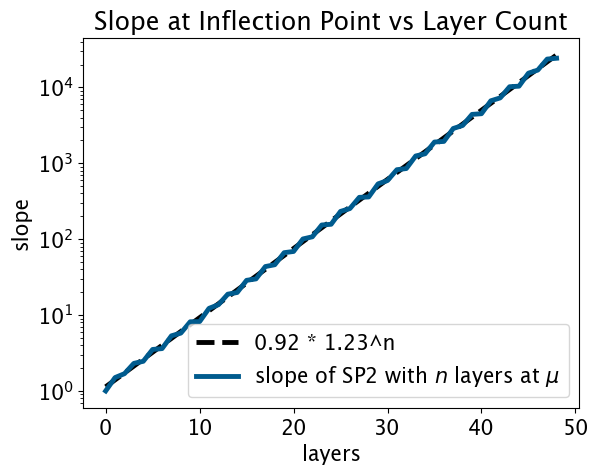

In [ ]:
def slope(mu, N):
    W, mus = SP2_weights(N,mu)
    return jax.jvp( lambda x: quad(x, W), (mu,), (1.,) )

def slope_(mu, N):
    W, mus = SP2_weights(N,mu)
    return jax.jvp( lambda x: quad(x, W), (mus[-1],), (1.,) )

phi_ = 2/(1 + jnp.sqrt(5))
mu_x = 0.5

N = 50

lrs = jnp.arange(1,N)
slopes  = jnp.array([ slope (mu_x, n)[1] for n in lrs ])
slopes_ = jnp.array([ slope_(mu_x, n)[1] for n in lrs ])


m, b = np.polyfit(lrs[10:], np.log(slopes)[10:], 1)

plt.semilogy(jnp.exp(m * lrs + b), 'k--', label=f'{jnp.exp(b):.2} * {jnp.exp(m):.2f}^n')
plt.semilogy( slopes, label=r'slope of SP2 with $n$ layers at $\mu$' )
#plt.semilogy( slopes_, label=r'slope of SP2 with $n$ layers at $\mu_n$' )

plt.title('Slope at Inflection Point vs Layer Count')
plt.xlabel('layers')
plt.ylabel('slope')
plt.legend()

#plt.axhline(100/4, c='k', ls='--', lw=1)

print(1/m, (jnp.log(4))/m, b/m)

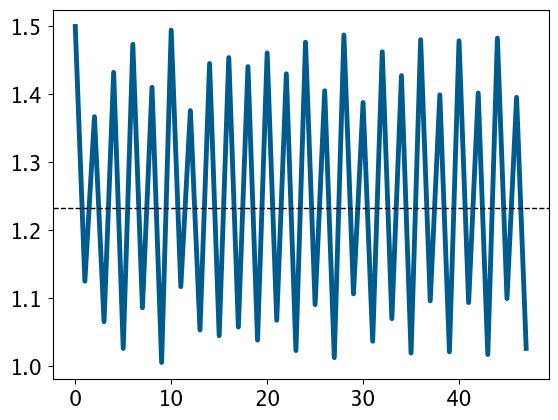

In [ ]:
plt.plot( slopes[1:] / slopes[:-1] )
#plt.plot( slopes_[1:] / slopes_[:-1] )
plt.axhline(jnp.exp(m), c='k', ls='--', lw=1)

geo = slopes[1:] / slopes[:-1]

#plt.plot( [ geo[:i].mean() for i in lrs] )

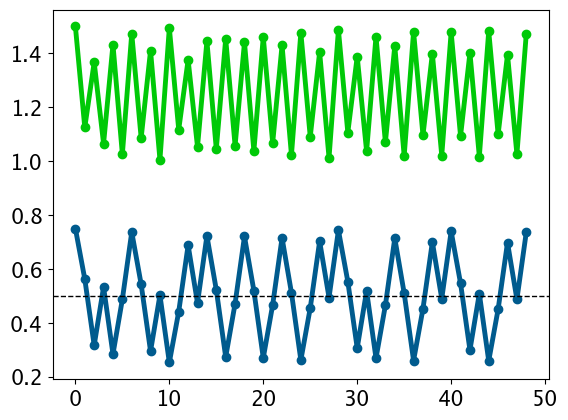

In [ ]:
W, mus = SP2_weights(N,mu_x)
sigma = W[:,2]

def f_ip(f, s):
    return 2 * f if s > 0 else 2 - 2 * f

plt.plot( [ quad(mu_x, jnp.array(W)[:i].at[-1,-1].set(1)) for i in range(1,N) ], 'o-' )
plt.plot( [ f_ip( quad(mu_x, jnp.array(W)[:i].at[-1,-1].set(1)), sigma[i]) for i in range(1,N) ], 'o-' )
plt.axhline(0.5, **axline)

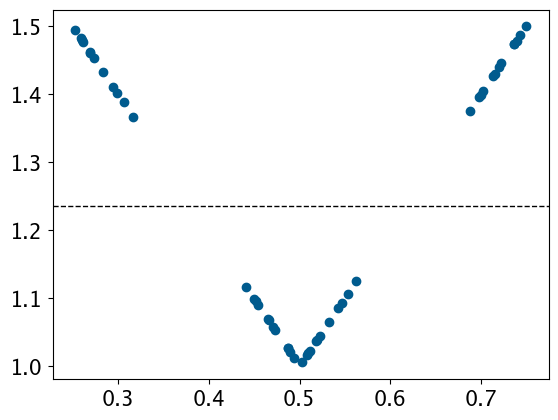

In [ ]:
X = [ quad(mu_x, jnp.array(W)[:i].at[-1,-1].set(1)) for i in range(1,N) ]
Y = [ f_ip( quad(mu_x, jnp.array(W)[:i].at[-1,-1].set(1)), sigma[i]) for i in range(1,N) ]

plt.axhline(2*phi_, **axline)
plt.scatter(X,Y)

#plt.scatter(X, (lambda x : 1 + 2 * jnp.abs(jnp.array(x) - 0.5))(X) )

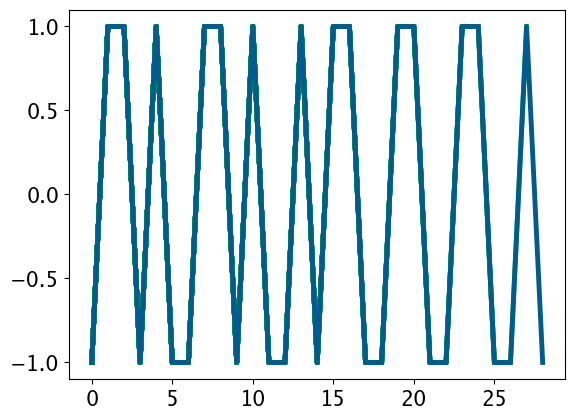

In [ ]:
for N in range(1,30):
    sigma = SP2_weights(N,mu_x)[0][:,2]
    plt.plot(sigma)

## SP2

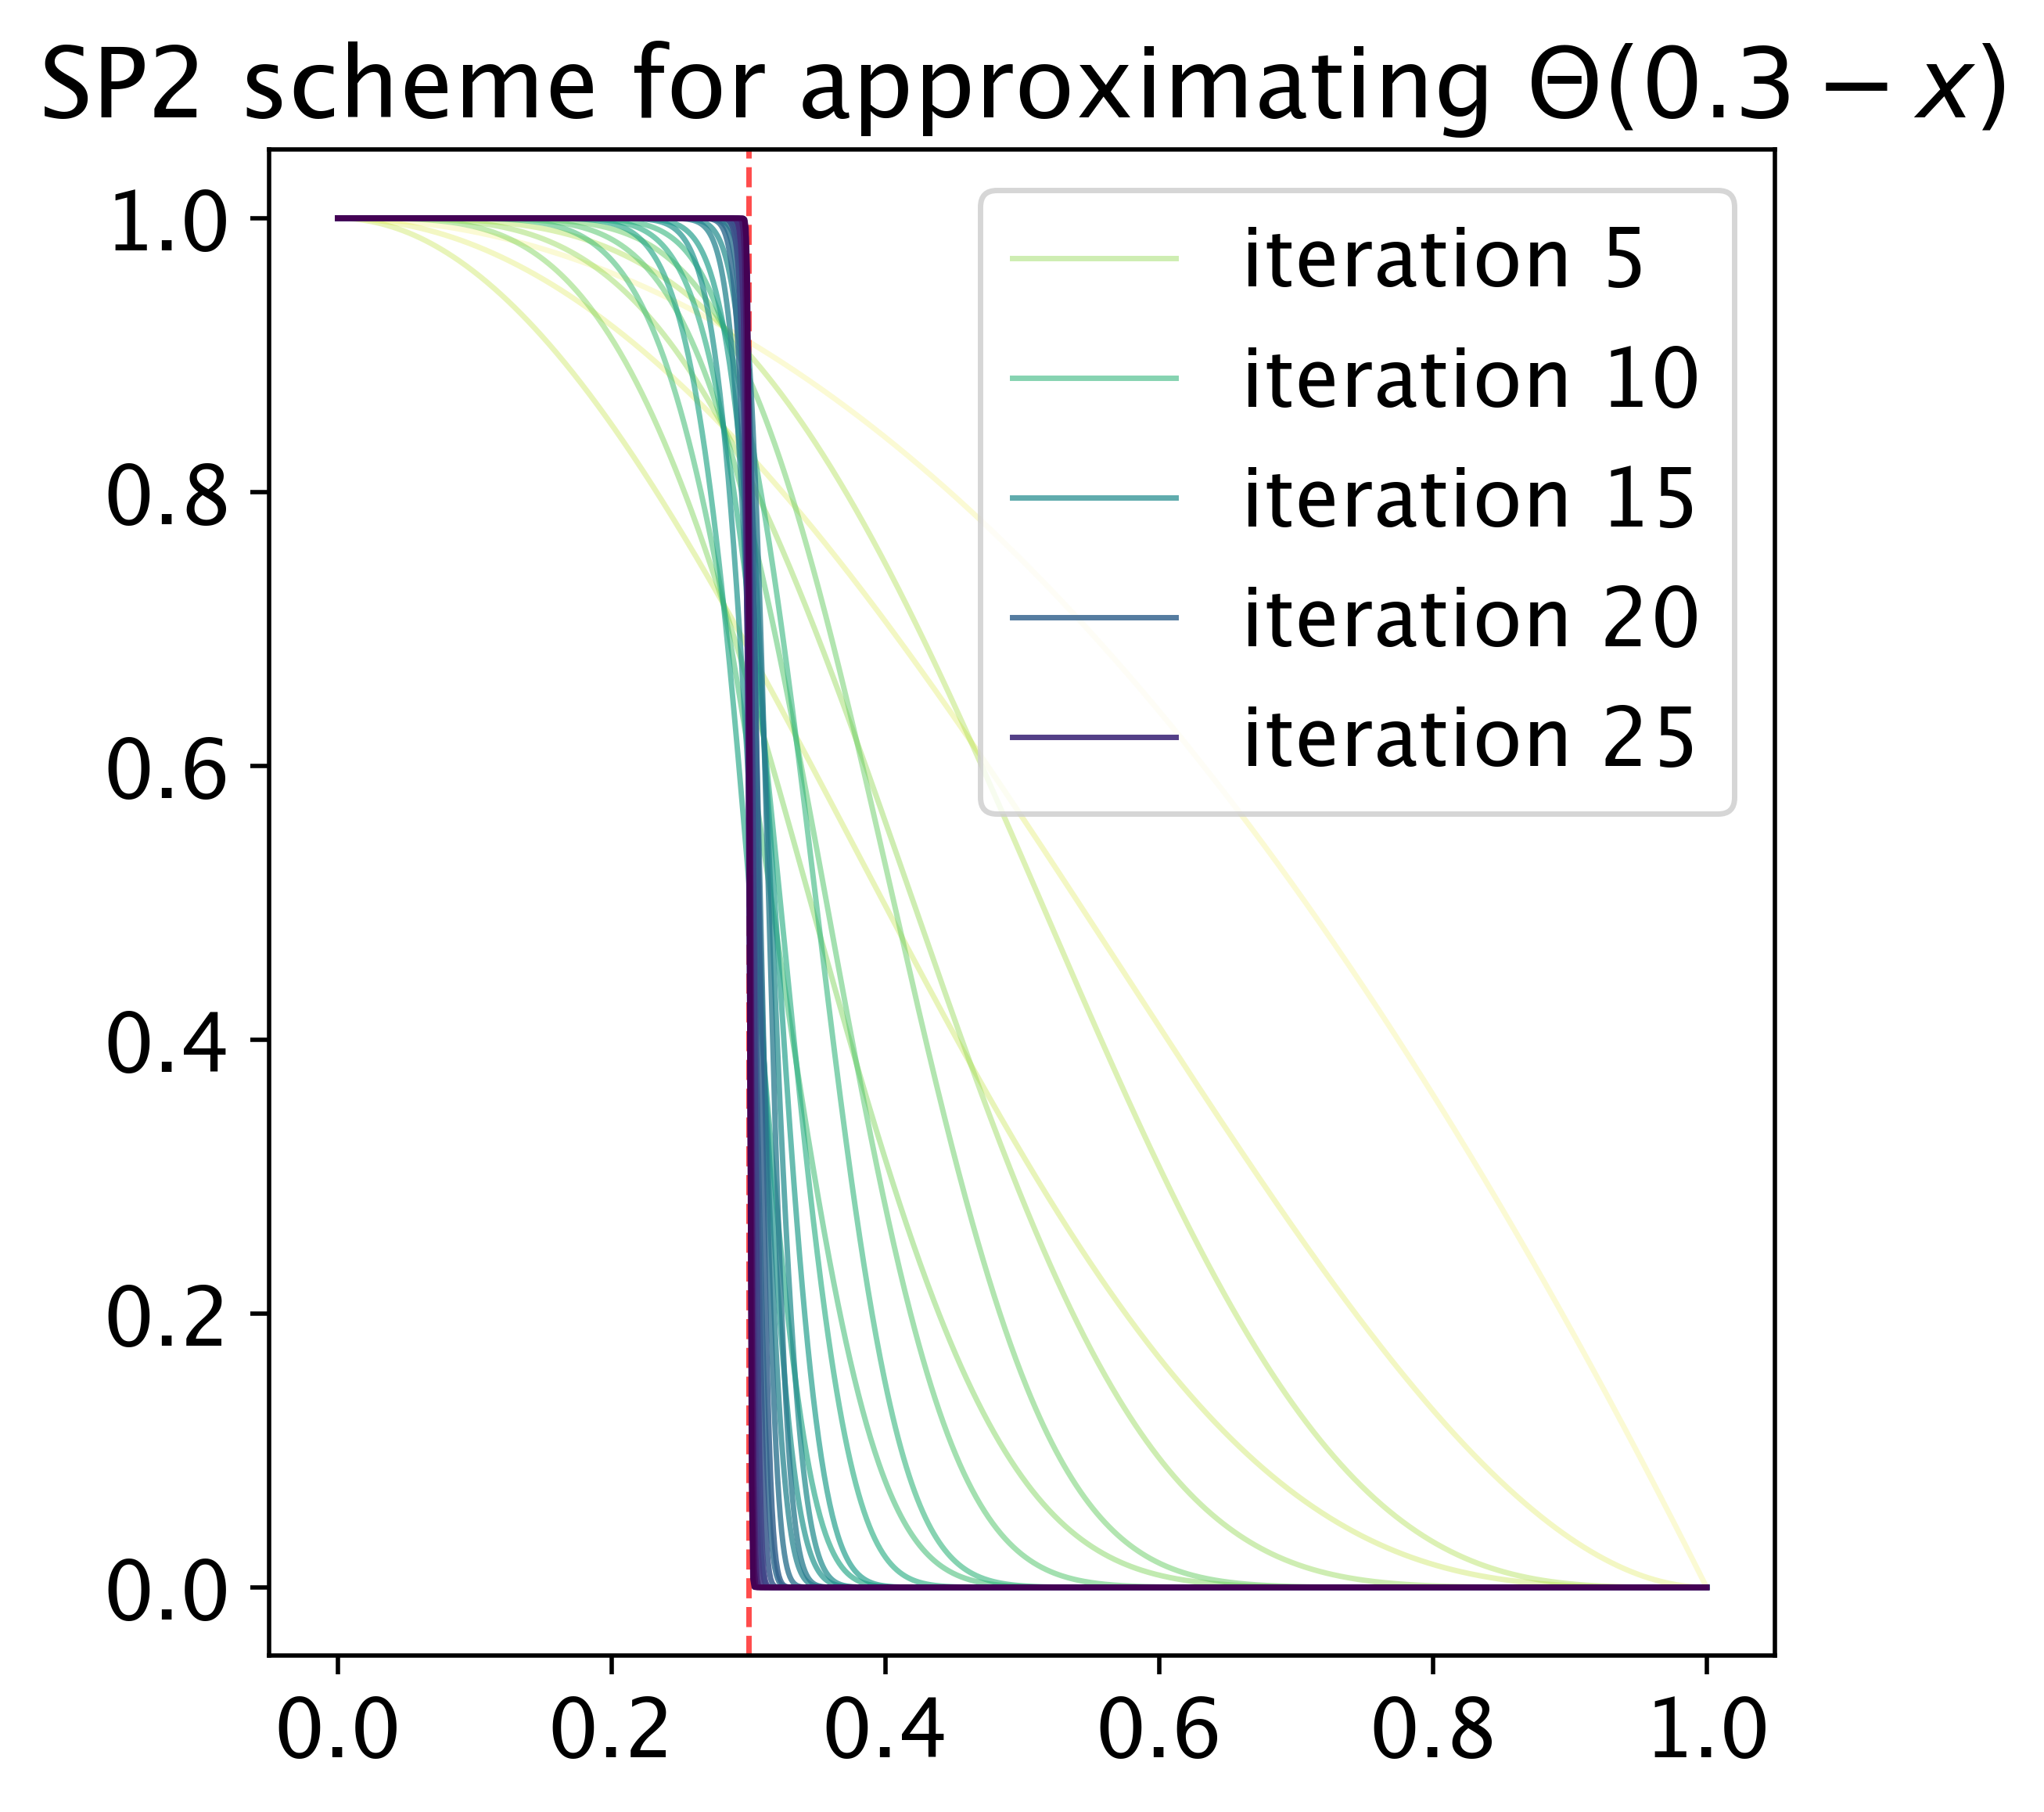

In [ ]:
W_SP2, mus = SP2_weights(N, mu)

x = jnp.linspace(0,1,1000)

plt.figure(figsize=(5,5), dpi=500)
plt.axvline(mu, c='r', ls='--', lw=1, alpha=0.7)

for i in range(1,N+1):
    plt.plot( x, 1-quad(x, jnp.array(W_SP2)[:i].at[-1,-1].set(1)), c=clr(1-i/N), linewidth=1, alpha=(i/N)**0.5, label=f'iteration {i}' if not i % 5 else None)

plt.title(f'SP2 scheme for approximating $\\Theta({mu}-x)$')
plt.axis('square')

plt.legend()

plt.savefig(fig_path + 'SP2.pdf', bbox_inches='tight')

## SP2 vs MLSP2

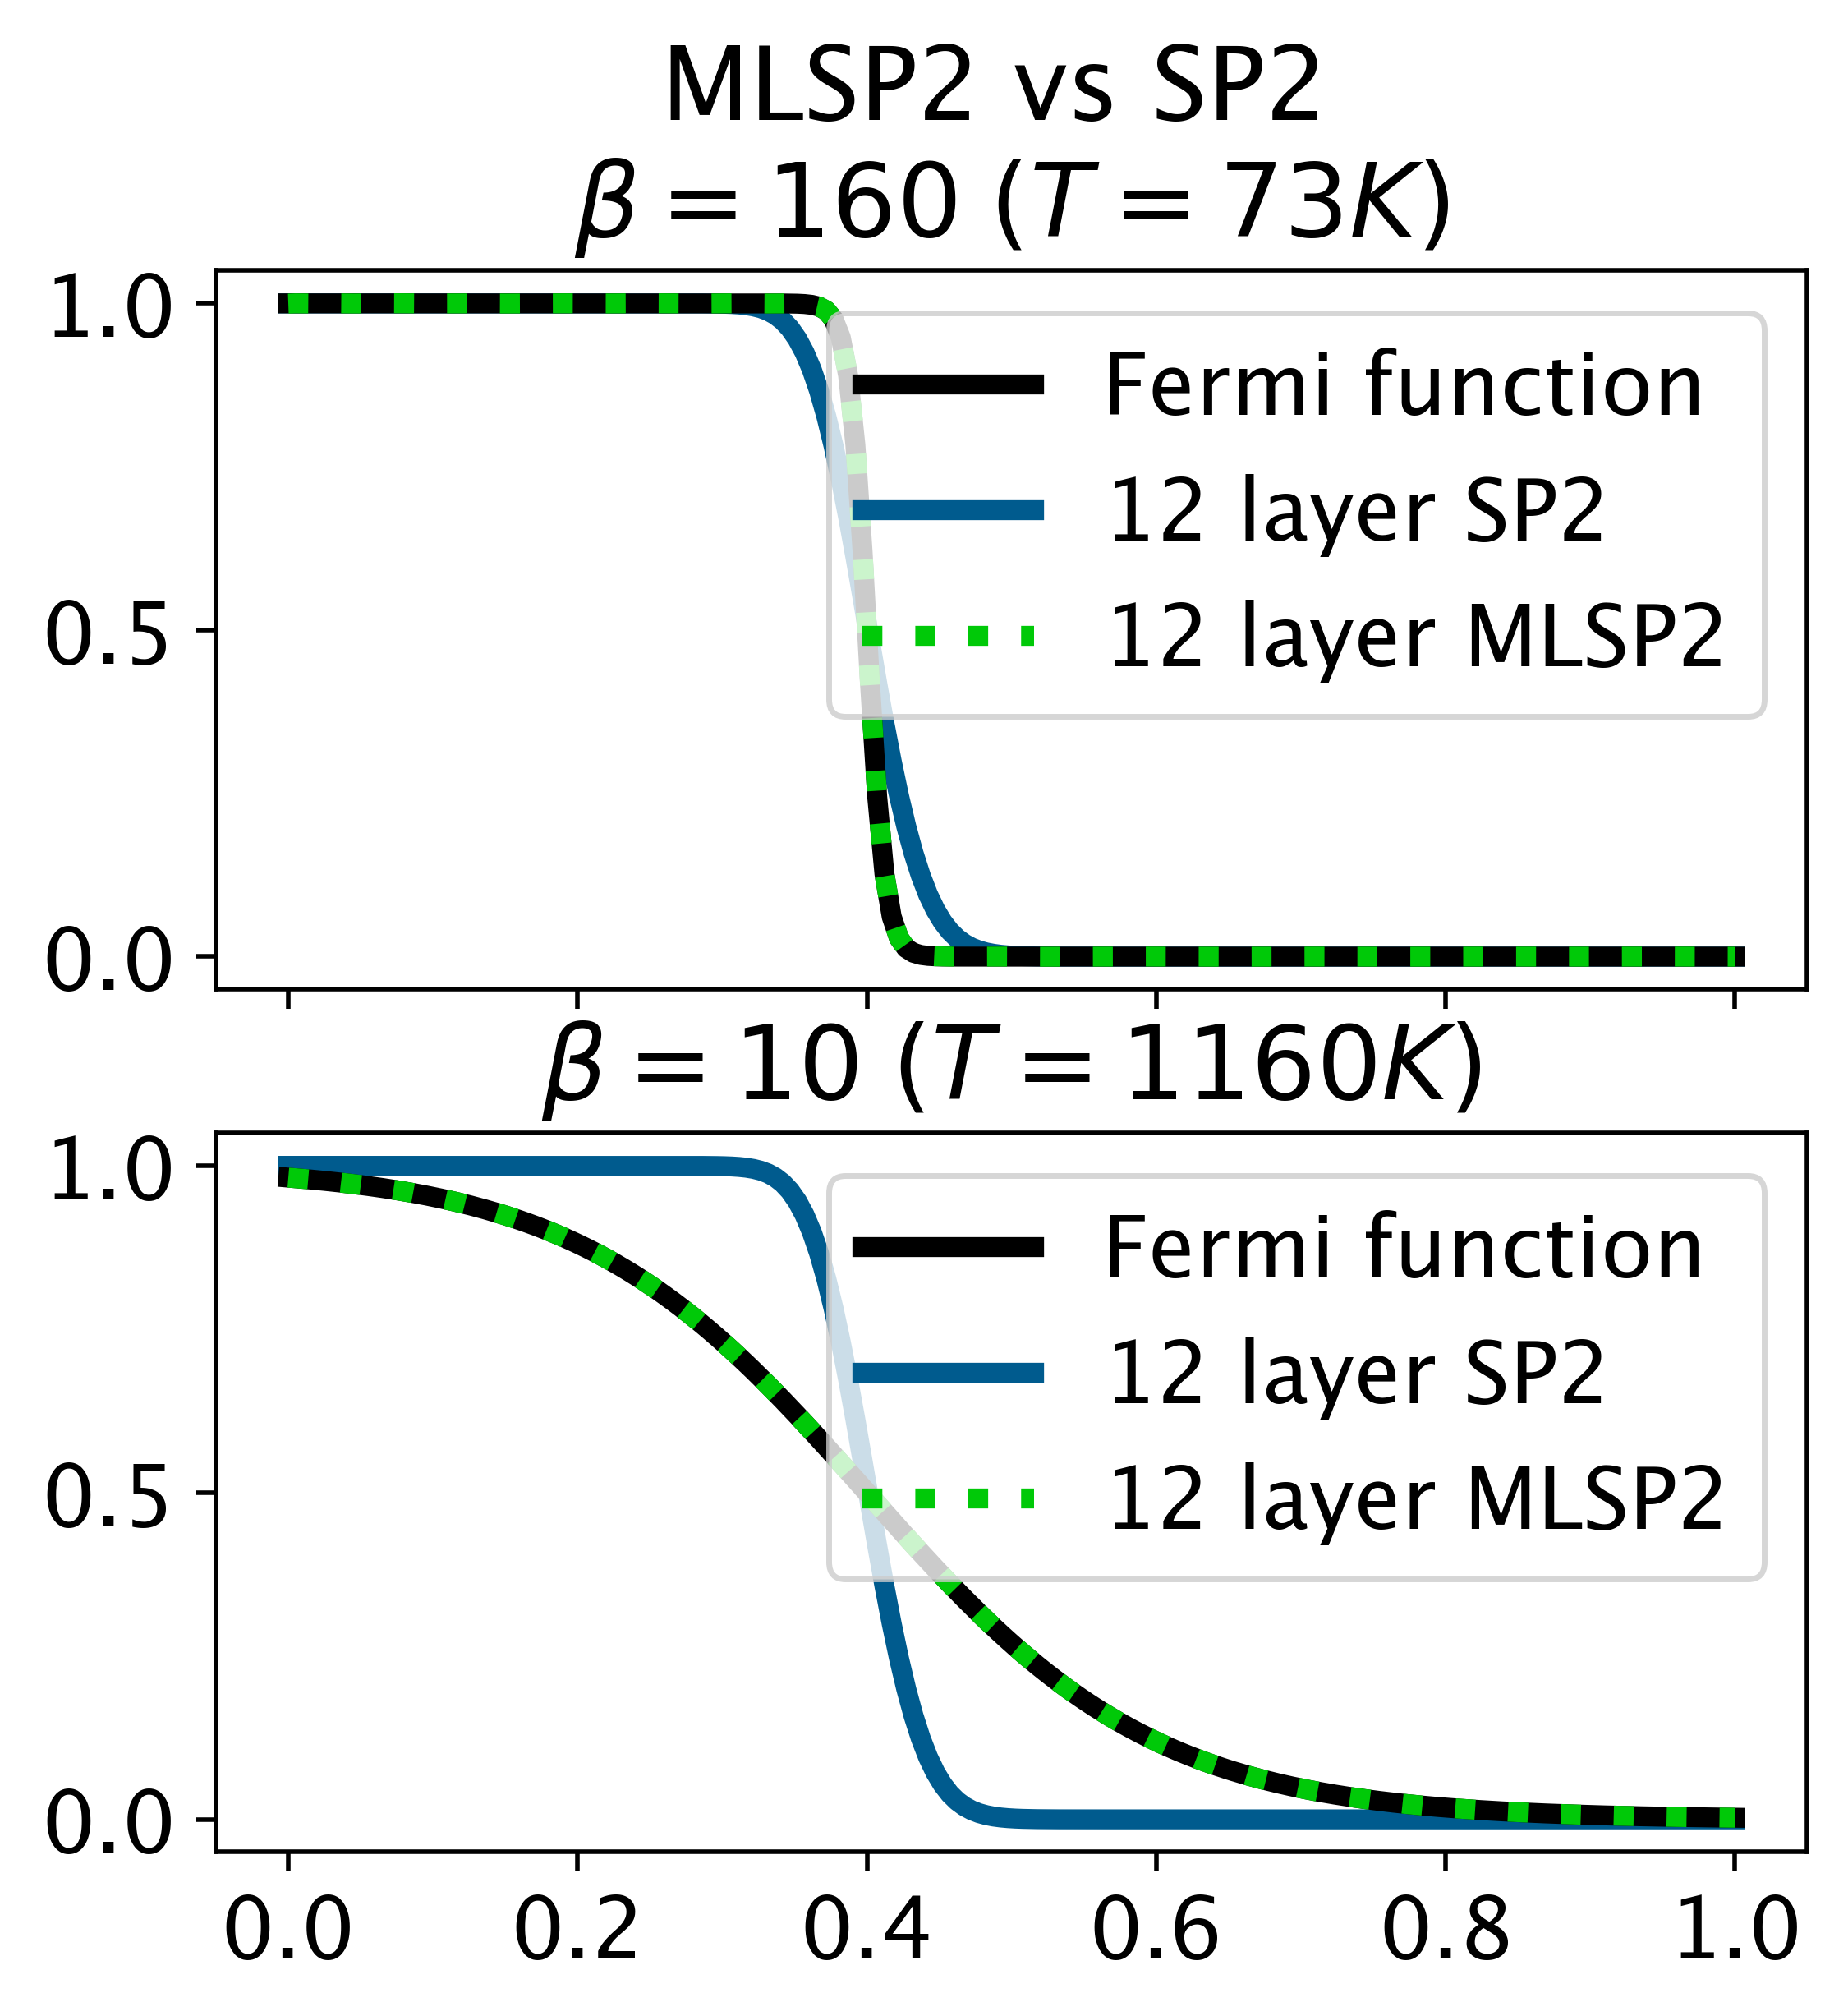

In [ ]:
# 12 layer comparison

W_sp2 = [-1.0, 2.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, -1.0, 2.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, -1.0, 2.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, -1.0, 2.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, -1.0, 2.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, -1.0, 2.0, 0.0, 0.0]
W_160 = [-1.3107397429574055, 2.145267207444592, -0.1740029642730165, -0.00016852482611356322, 1.2956573584559612, -0.31691285801145397, -0.04779055453900641, 0.0002071731190945131, -4.547694077967698, 2.374618694870437, 0.012233046012636424, 0.0002773526004132892, 2.12212949094235, 0.11981469147386352, -0.04732757025510901, 0.00023419055262489938, -7.895884196770281, 2.692782902441595, 0.03846448184195957, 0.0017100994223981187, 3.655445606260067, 0.33419138430380335, -0.054808766454144266, 0.0008347824613780589, -5.05827224282492, 2.7113770850396324, 0.06826034026098615, 0.02678527364901705, 4.337049317503328, 0.45287007962870196, -0.05093325387508539, 0.01912934860840706, -1.1521944519515246, 2.0709523711766353, 0.050259709537291156, 0.13860782038130065, 1.560072095928151, 0.1666166389238657, -0.20159580228521135, -0.027854553203082364, 0.29888240059659904, -0.1504198140727192, 0.09760310000170745, 0.4358682180620962, -1.4627379670483158, 1.6758842121466377, -0.06303905036414413, -0.32411578785141515]
W_10  = [-0.7461045259982055, 1.7425790940313448, 0.08506569839702853, 0.0032779377306902985, 0.5348087000752003, 0.1538651831761095, 0.044201414562134916, 0.021155175402184548, -1.0129314807239271, 1.9152427529331792, 0.00606495999102541, -0.0329293305297388, 0.80612962346825, 0.01575026422622649, 0.05710106846178743, 0.04078115981805791, -1.1334100458411378, 1.945884422864513, 0.003943033867230677, -0.1617730033738127, 0.9085815411282093, 0.0212565101613872, 0.07855133221386079, 0.18051736341467509, -1.093107908013023, 1.9666915639328026, 0.02340316395200027, -0.18053490669852484, 0.9507606311326144, 0.09342150782732023, 0.017688467458506666, 0.320171172096929, 2.2411449369942402, 2.197024268085066, -0.1157604823292246, 0.34776658788214126, 0.5468031580424484, -0.9254417614907114, -0.19264845382067383, 0.22152189415701232, 0.00010387255284109816, -0.28256525982097325, -0.03471252020150715, 0.2479143093476767, 0.0013378819787887588, 1.5146595406094256, -0.06474637732345237, -0.485340433399273]

W_sp2, W_160, W_10 = reshape_W(W_sp2), reshape_W(W_160), reshape_W(W_10)

x = jnp.linspace(0,1,200)

plt.figure(figsize=(5,5), dpi = 500)
plt.subplot(211)

beta_demo = 160

plt.title(f"MLSP2 vs SP2 \n$\\beta = {beta_demo} \\; (T = {1/(kB*beta_demo):.0f}K)$")
plt.plot( x, modelj(x, W_sp2), colors[1], label=f'{len(W_sp2)} layer SP2')
plt.plot( x, 1/(1 + jnp.exp(beta_demo * (x - 0.4))), 'k', label='Fermi function' )
plt.plot( x, modelj(x, W_160), ':', c=colors[3], label=f'{len(W_160)} layer MLSP2')
plt.tick_params('x', labelbottom=False)

handles, labels = plt.gca().get_legend_handles_labels()
order = [1,0,2]
plt.legend([handles[idx] for idx in order],[labels[idx] for idx in order])

plt.subplot(212)

beta_demo = 10

plt.title(f"$\\beta = {beta_demo} \\; (T = {1/(kB*beta_demo):.0f}K)$")
plt.plot( x, modelj(x, W_sp2), colors[1], label=f'{len(W_sp2)} layer SP2')
plt.plot( x, 1/(1 + jnp.exp(beta_demo * (x - 0.4))), 'k', label='Fermi function' )
plt.plot( x, modelj(x, W_10), ':', c=colors[3], label=f'{len(W_10)} layer MLSP2')

handles, labels = plt.gca().get_legend_handles_labels()
order = [1,0,2]
plt.legend([handles[idx] for idx in order],[labels[idx] for idx in order])

plt.savefig(fig_path + 'SP2 vs MLSP2.pdf', bbox_inches='tight')

## Trust Region

In [ ]:
path = "/Users/skowalski/Desktop/Weights/"

W_new = reshape_W(np.load(path + "fermi_30.npz"))

beta_new, mu_new = 40, 0.3

def targ(x, beta, mu):
    return 1/(1 + jnp.exp( beta * (x - mu) ))

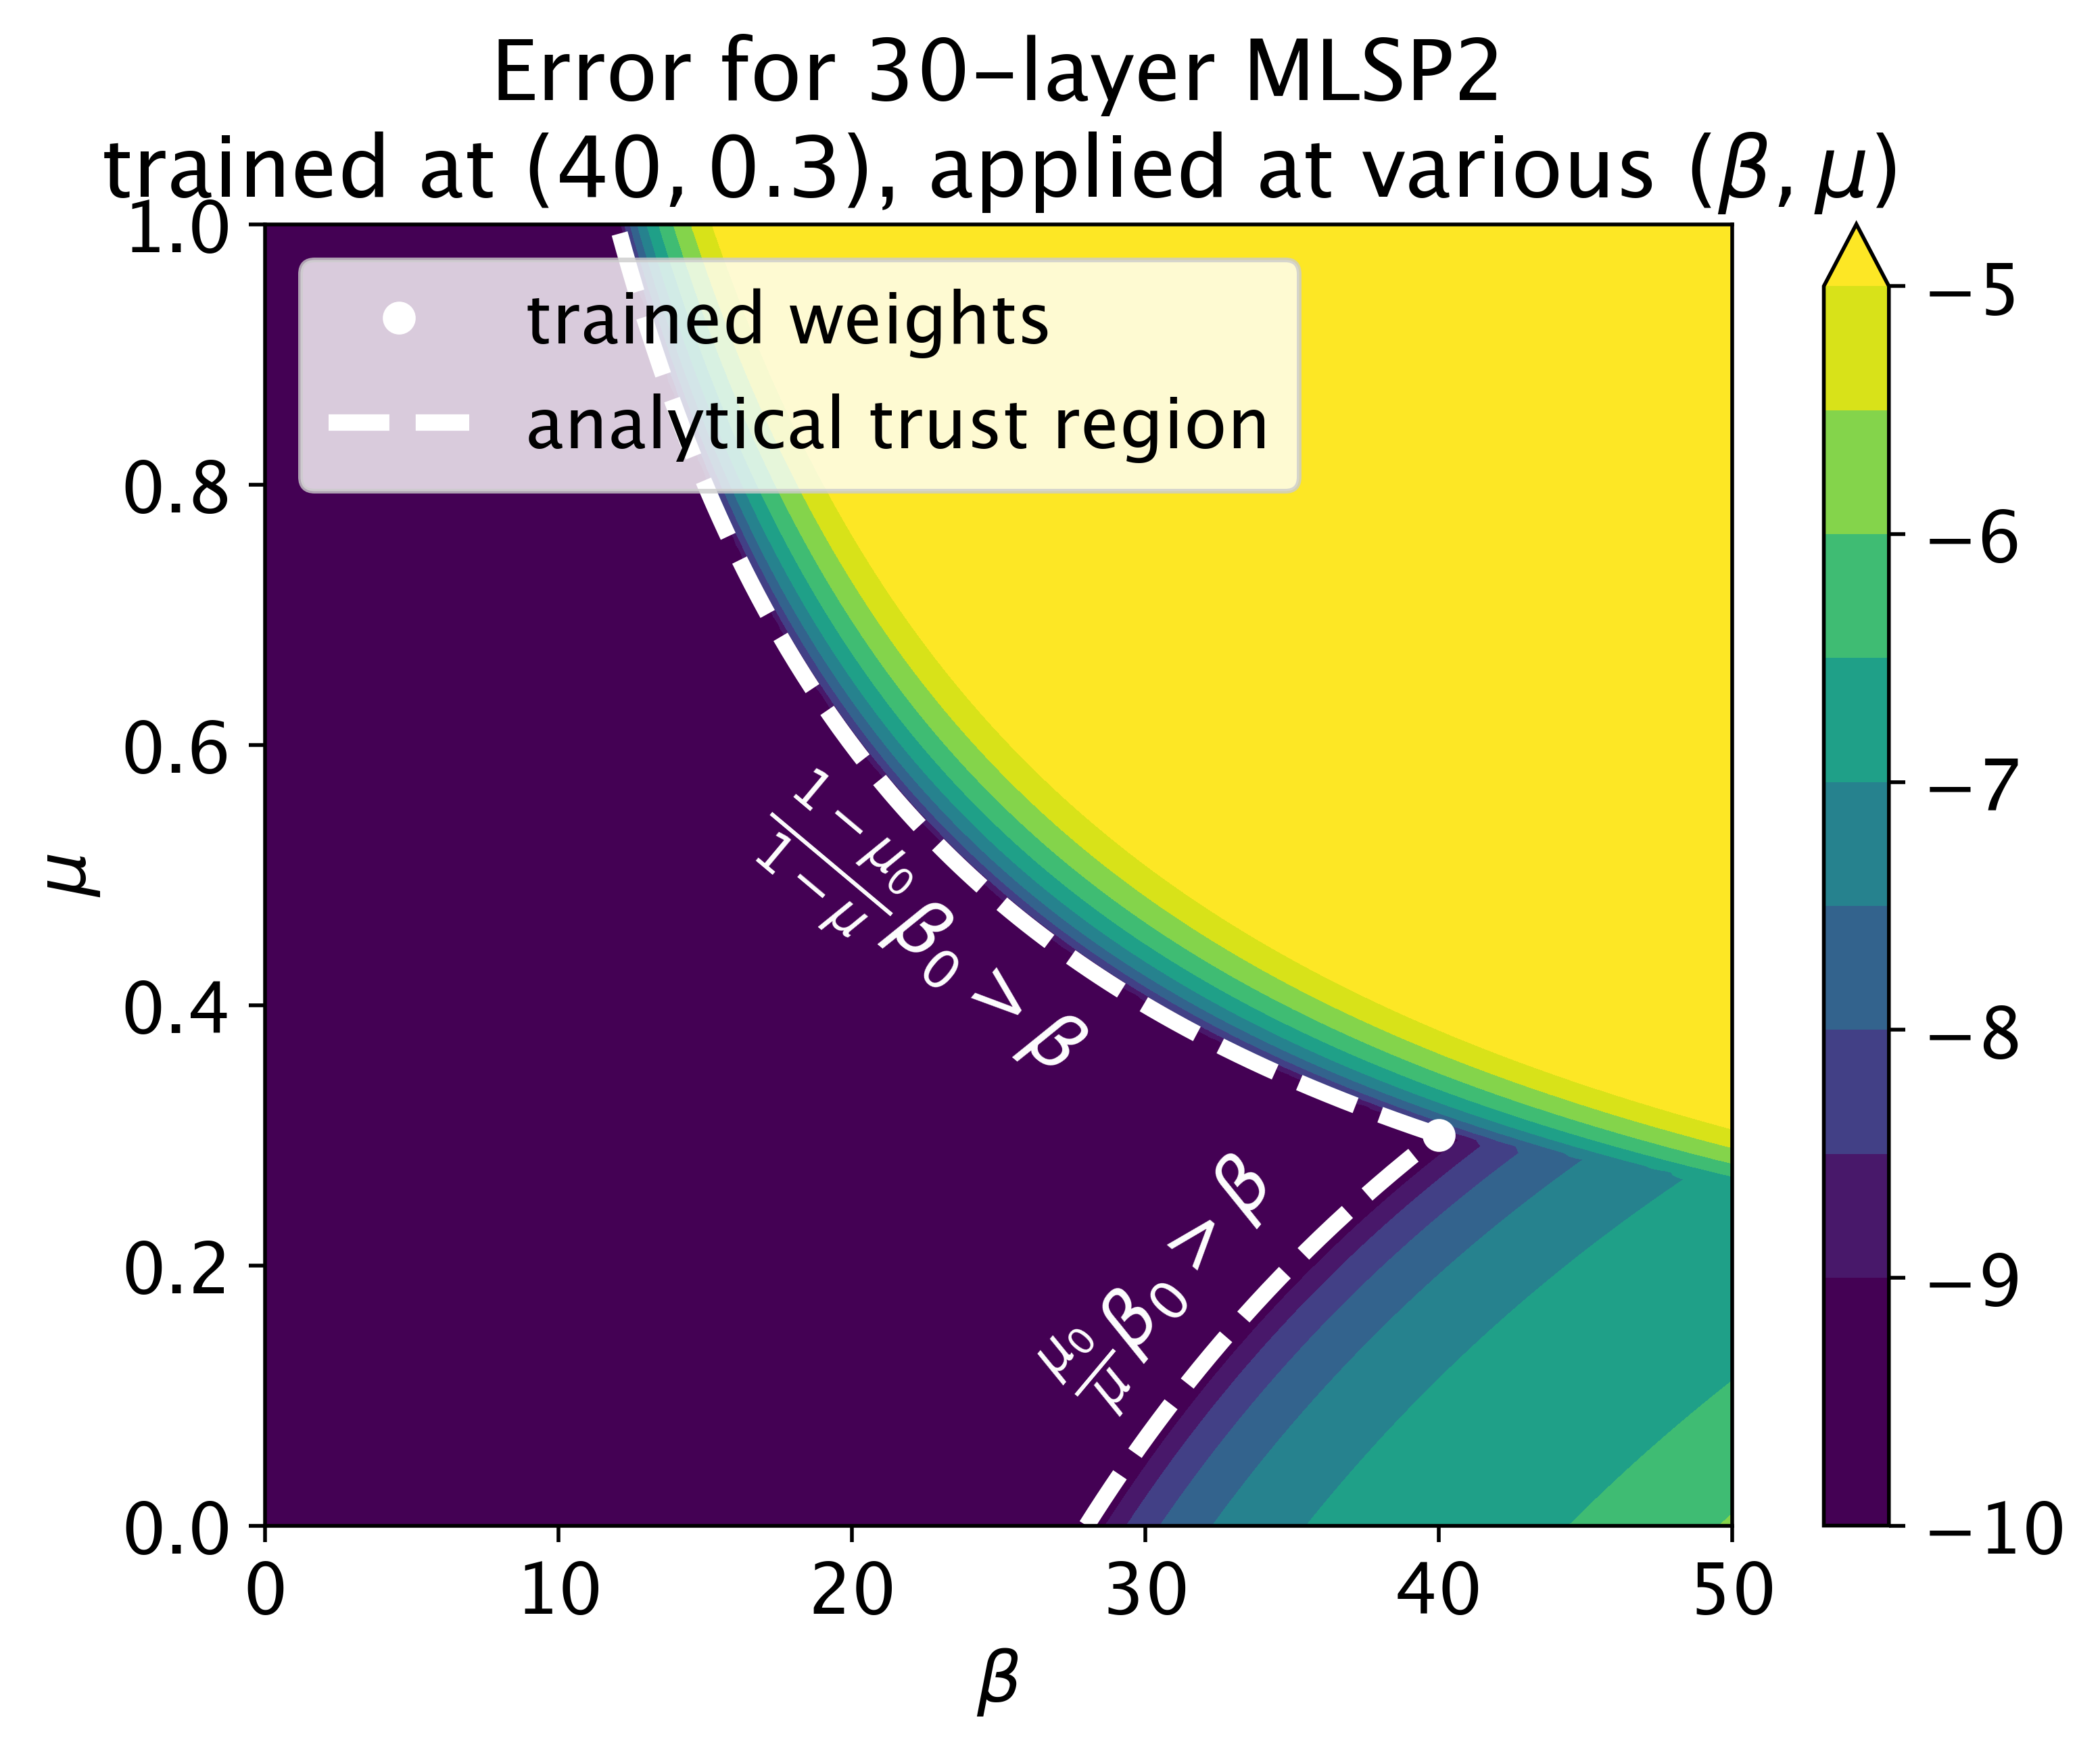

In [ ]:
col = 'w'

N_mesh = 200

betas = jnp.linspace(-beta_new, 10,  N_mesh) + beta_new
mus   = jnp.linspace(0, 1, N_mesh)

B, M = jnp.meshgrid(betas, mus)

def error_scaled(b,m,x):
    x_new = b/beta_new * (x - m) + mu_new
    y_new = targ(x, b, m)

    return jnp.max(jnp.abs(modelj( x_new, W_new ) - y_new ), axis=0)

err_rescale = error_scaled(B[None,:,:], M[None,:,:], jnp.linspace(0,1,200)[:,None,None])

log_err = jnp.log10(jnp.nan_to_num(err_rescale, nan=jnp.inf))

levels = jnp.arange(jnp.floor(jnp.min(log_err)), -4.5, 0.5)

plt.figure(figsize=(7,5), dpi=500)

plt.contourf(betas, mus, log_err, levels=levels, vmax=-5, vmin=-9, extend='max', cmap=CMAP)
plt.colorbar()

plt.title(f"Error for {len(W_new)}-layer MLSP2\ntrained at $({beta_new},{mu_new})$, applied at various $(\\beta, \\mu)$")
plt.xlabel('$\\beta$')
plt.ylabel('$\\mu$')

plt.plot(beta_new, mu_new, col + 'o', label='trained weights')

def clip(x):
    x = jnp.where( x <= beta_new, x, jnp.nan)
    return x

zero_graph = (1 - mu_new)/(1 - mus) * beta_new
ones_graph = (mu_new)/(mus) * beta_new

gra = jnp.where( zero_graph < ones_graph, zero_graph, ones_graph )

plt.plot(clip(gra), mus, col + '--', label='analytical trust region')
#plt.plot(clip(ones_graph), mus, 'r--')

plt.text(gra[150], mus[150] - 0.4, '$\\frac{1 - \\mu_0}{1 - \\mu} \\beta_0 > \\beta$', c=col, rotation=-40, fontsize=16)
plt.text(gra[20] - 5, mus[20], '$\\frac{\\mu_0}{\\mu} \\beta_0 > \\beta$', c=col, rotation=50, fontsize=16)

plt.legend(loc='upper left')

plt.savefig(fig_path + 'trust region.pdf', bbox_inches='tight')

## Evaluation Speed

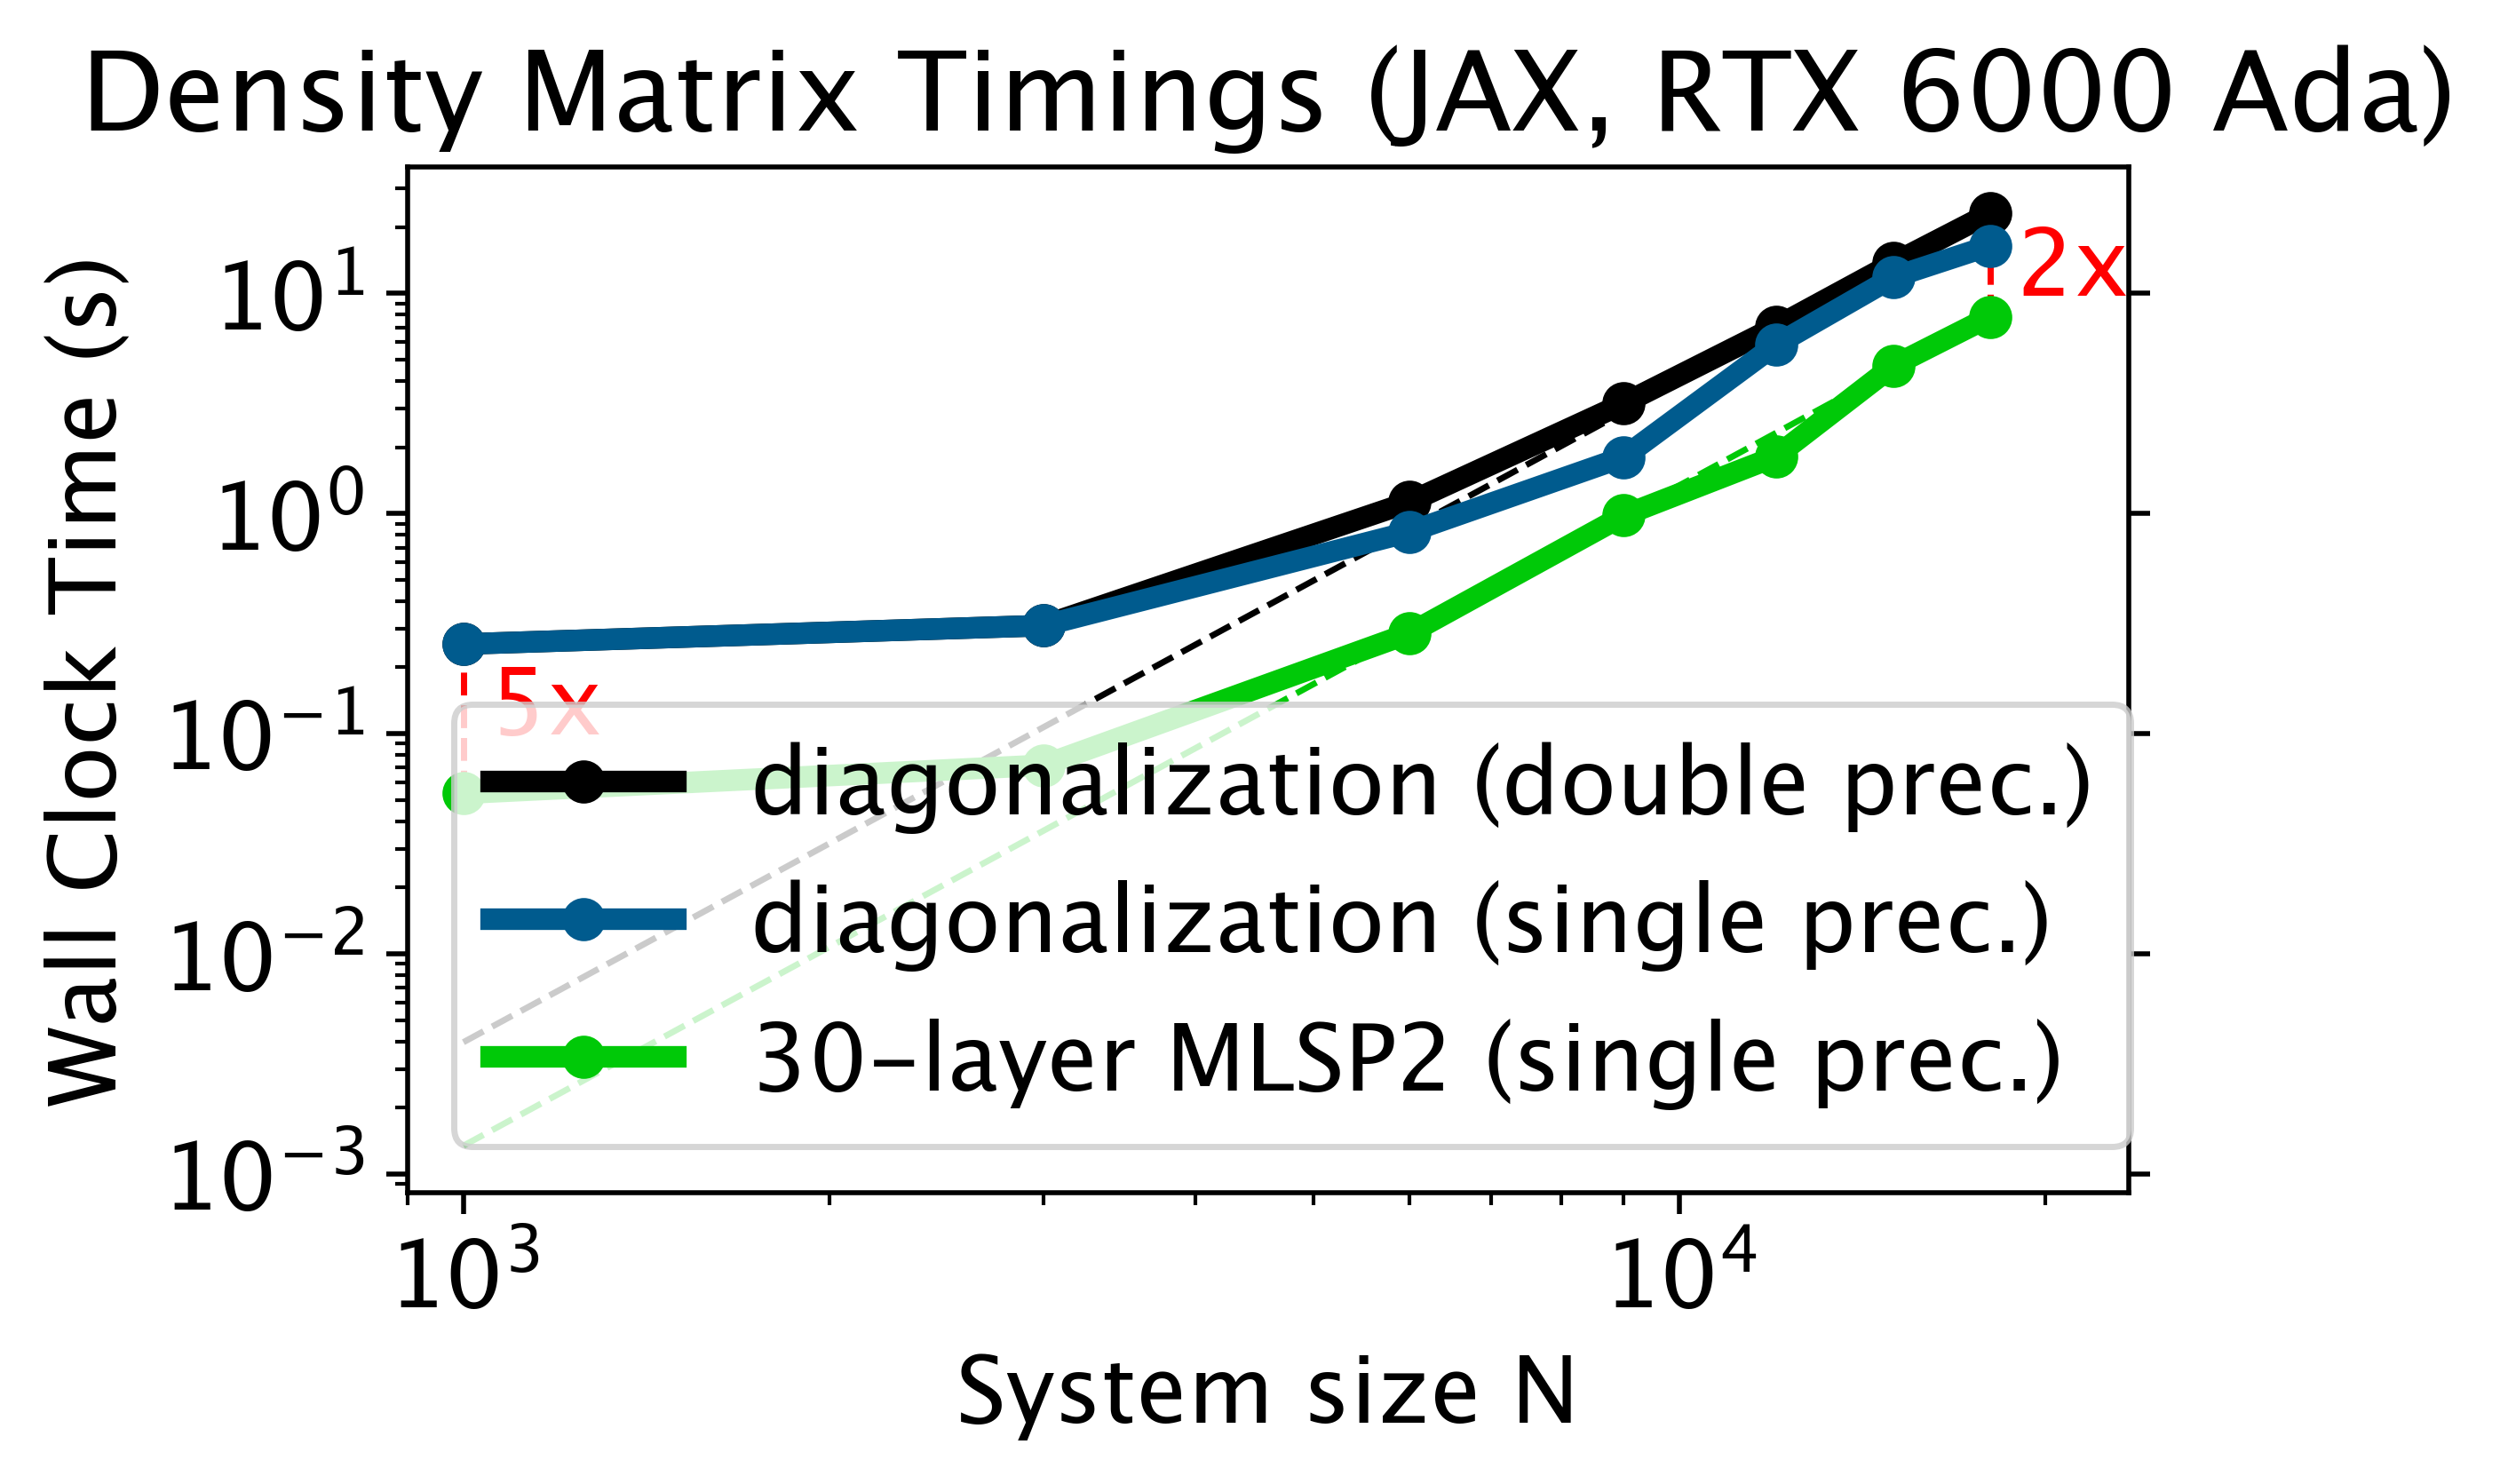

In [ ]:
Ns = [1000, 3000, 6000, 9000, 12000, 15000, 18000]
diag2 = [0.25525784492492676, 0.30959272384643555, 1.1287298202514648, 3.1630475521087646, 7.0456554889678955, 13.750117301940918, 23.11798906326294]
diag1 = [0.880180835723877, 0.6777133941650391, 0.8253908157348633, 1.8061306476593018, 5.834158182144165, 11.842714309692383, 16.47019624710083]
mlsp2 = [0.05355119705200195, 0.07184767723083496, 0.2859618663787842, 0.9798107147216797, 1.8162455558776855, 4.699090242385864, 7.82840895652771]
diag1_TC = [0.8127951622009277, 0.45258545875549316, 0.6736018657684326, 1.5664167404174805, 5.76566743850708, 11.543462038040161, 15.671980857849121]
mlsp2_TC = [0.05658316612243652, 0.06838512420654297, 0.2418217658996582, 0.7244553565979004, 1.7314305305480957, 3.5330803394317627, 5.975425481796265]

plot = plt.loglog

plt.figure(figsize=(5,3), dpi=500)

# cubic trendlines
plot(Ns, max(mlsp2) * (np.array(Ns)/max(Ns))**3, '--',  alpha=1, lw=1, c=colors[3])
plot(Ns, max(diag2) * (np.array(Ns)/max(Ns))**3, 'k--', alpha=1, lw=1)

#intermediate & asymptotic multipliers
plt.vlines(Ns[0], mlsp2[0], min(diag1[0], diag2[0]), color='r', linestyle='--', lw=1)
multiplier = min(diag1[0], diag2[0])/mlsp2[0]
plt.text(Ns[0]*1.05, mlsp2[0] * multiplier ** 0.4, f'{multiplier:.0f}x', c='r')

plt.vlines(Ns[-1], mlsp2[-1], min(diag1[-1], diag2[-1]), color='r', linestyle='--', lw=1)
multiplier = min(diag1[-1], diag2[-1])/mlsp2[-1]
plt.text(Ns[-1]*1.05, mlsp2[-1] * multiplier ** 0.3, f'{multiplier:.0f}x', c='r')

#data
plot(Ns, diag2,    'ko-', label='diagonalization (double prec.)')
plot(Ns, [a if a<b else b for a,b in zip(diag1,diag2)],    'o-', label='diagonalization (single prec.)')
#plot(Ns, diag1_TC, 'bx-', label='diagonalization (TC single prec.)')
plot(Ns, mlsp2,    'o-', label='30-layer MLSP2 (single prec.)')
#plot(Ns, mlsp2_TC, 'rx-', label='MLSP2 (TC single prec.)')

plt.tick_params(right=True)

plt.title('Density Matrix Timings (JAX, RTX 6000 Ada)')
plt.legend()
plt.xlabel('System size N')
plt.ylabel('Wall Clock Time (s)')

plt.xlim(Ns[0]*0.9, Ns[-1]*1.3)

plt.savefig(fig_path + 'evaluation speed.pdf', bbox_inches='tight')

## Affine Grid

In [ ]:
path = "/Users/skowalski/Desktop/dragonscale/"

W_drag = [[],[]]

indices = range(2,8)

B = [[3**i for i in indices], [2 * 3 ** i for i in indices]]
M = [[1/2] * len(indices) ,[1/4] * len(indices)]

for i in indices:
    W_drag[0].append( reshape_W(np.load(path + "P0/" + f"fermi_{i}.npz")) )
    W_drag[1].append( reshape_W(np.load(path + "P1/" + f"fermi_{i}.npz")) )

0.25 54
0.25 162
0.25 486
0.25 1458
0.25 4374


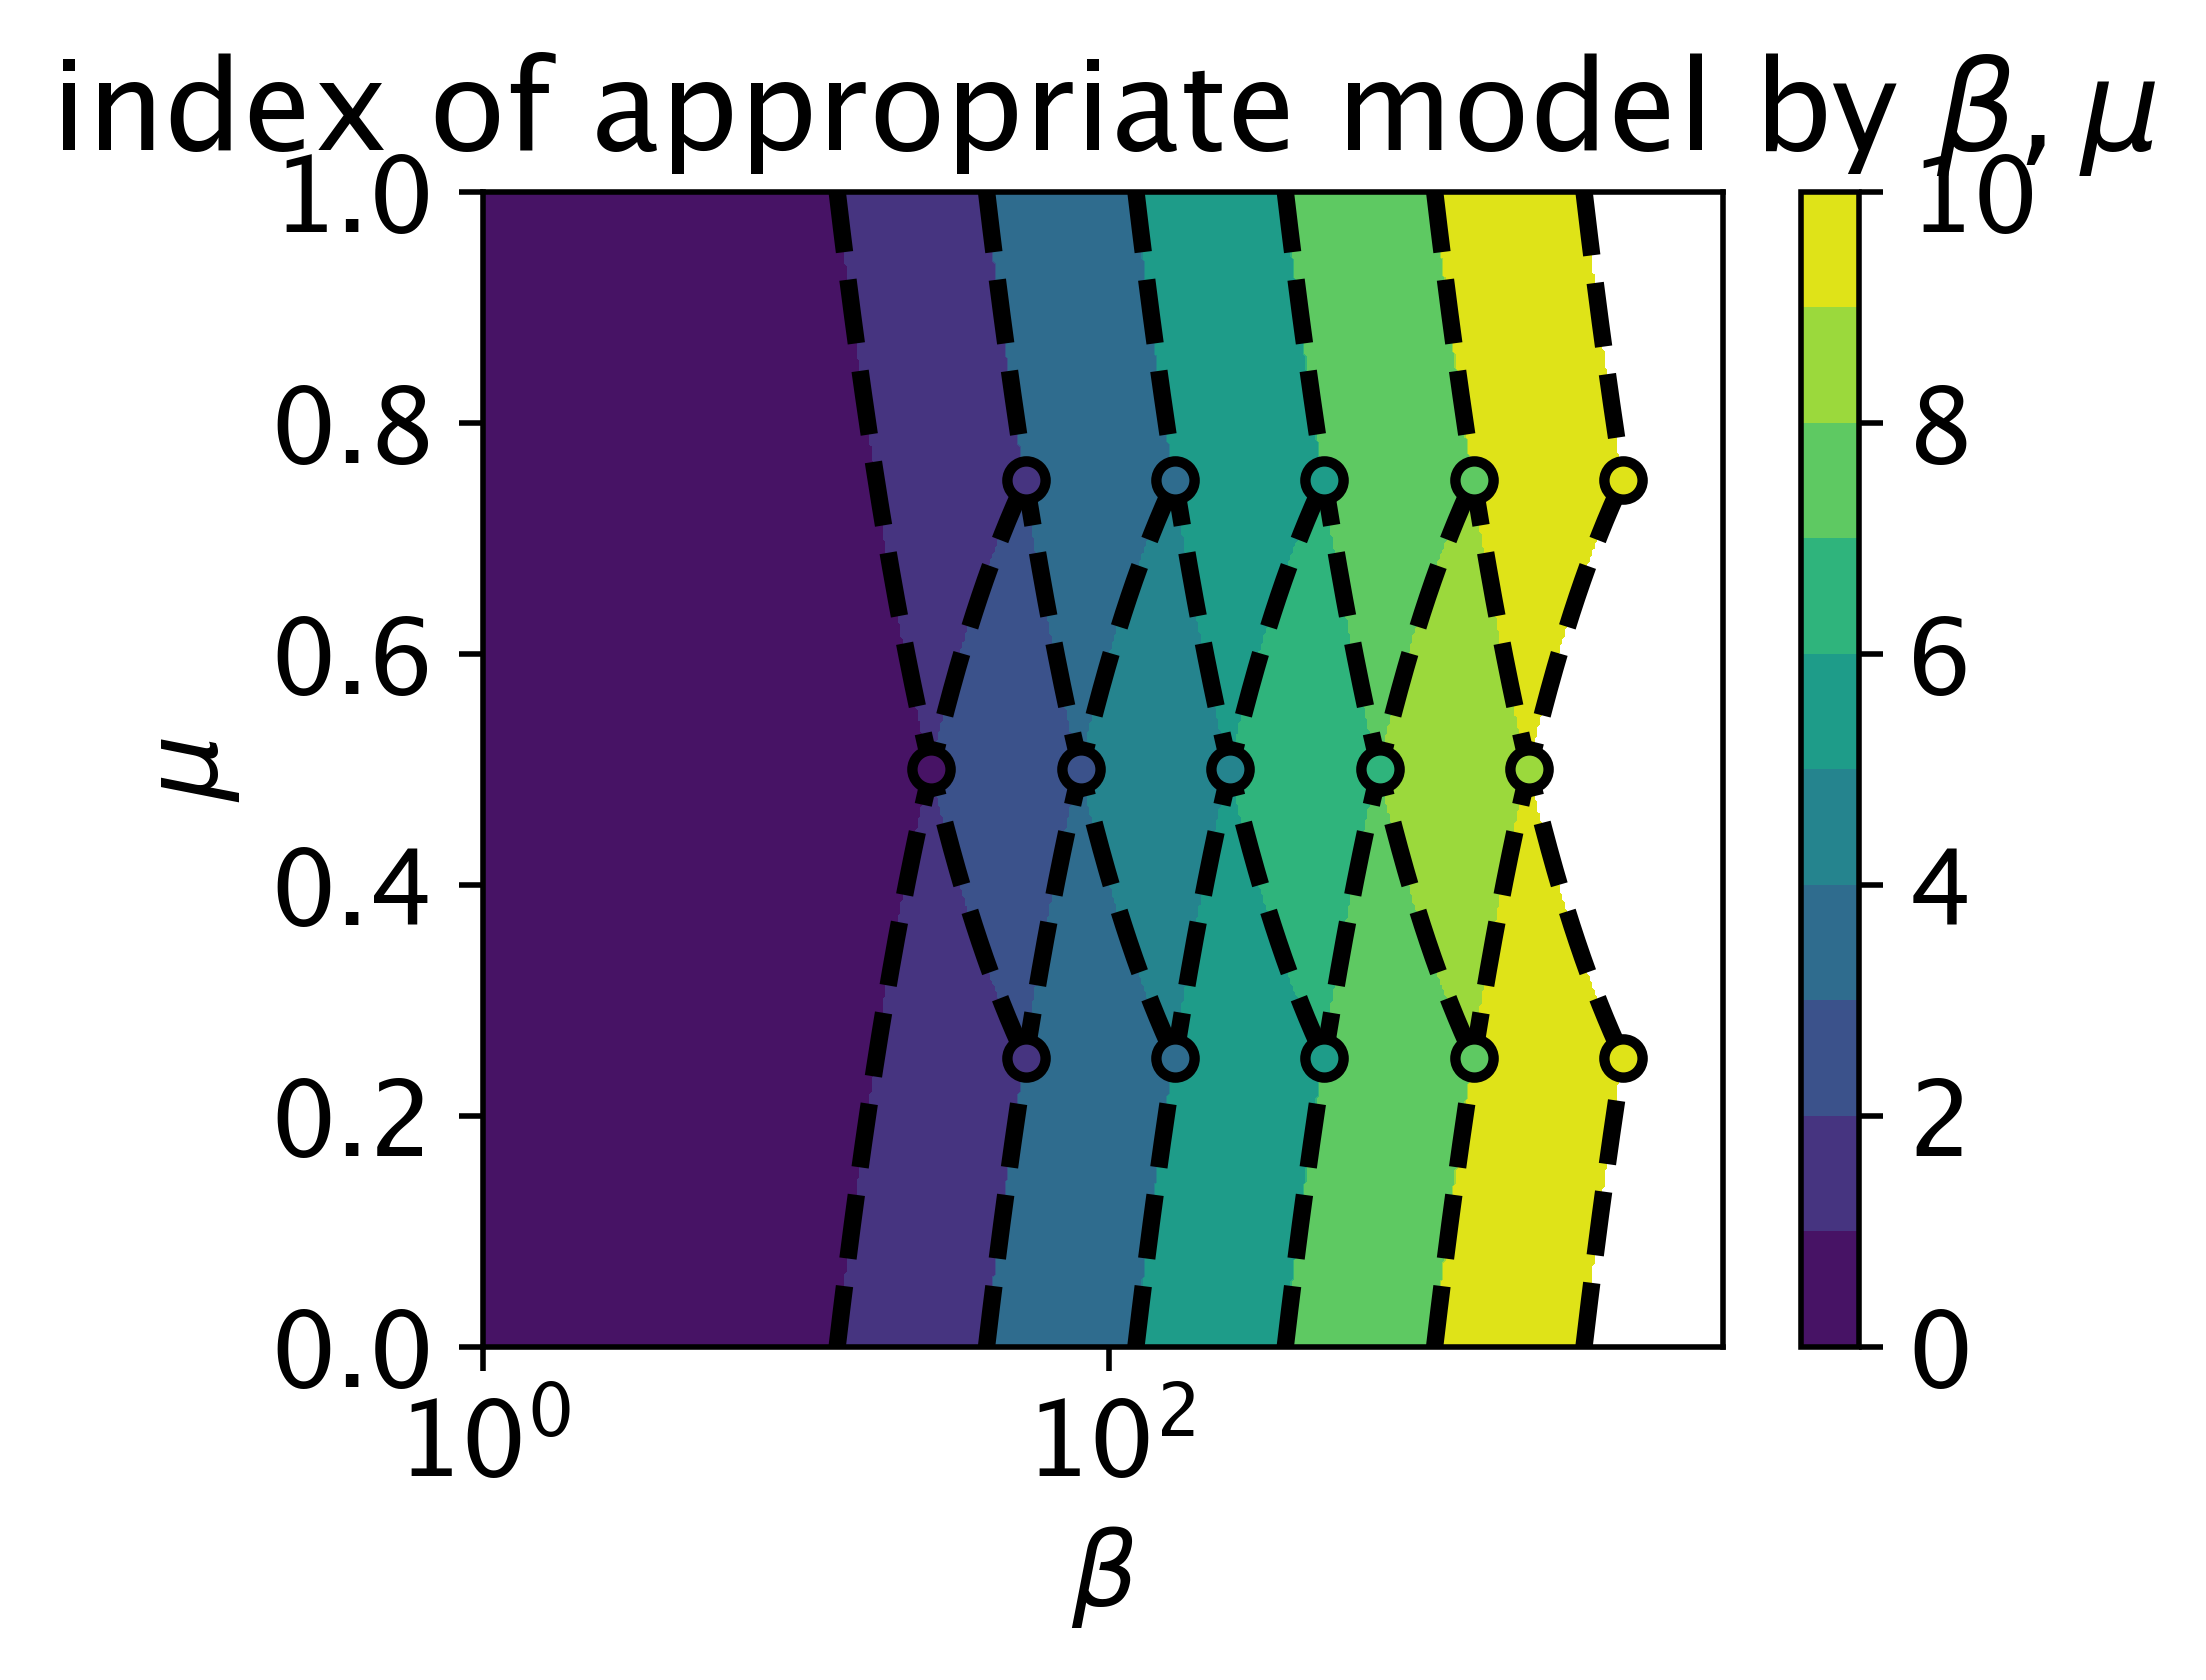

In [ ]:
N_mesh = 500

betas = jnp.logspace(0, jnp.log10(max(B[1])) + 0.32,  N_mesh)
mus   = jnp.linspace(0, 1, N_mesh)

bs, ms = jnp.meshgrid(betas, mus)

def indexing(b,m):
    m = jnp.where(m <= 0.5, m, 1-m)

    B0, M0 = jnp.array(B[0])[:,None, None], jnp.array(M[0])[:,None, None]
    B1, M1 = jnp.array(B[1])[:,None, None], jnp.array(M[1])[:,None, None]

    in_mid = ( (1 - M0)/(1 - m) < b/B0 ) | ( M0/m < b/B0 )
    in_low = ( (1 - M1)/(1 - m) < b/B1 ) | ( M1/m < b/B1 )

    x  = jnp.sum( in_mid, axis = 0) + jnp.sum( in_low, axis = 0) - 1
    return jnp.clip( x, 0, 11 )

idx = indexing( bs[None, :, :], ms[None, :, :] )

#idx = jnp.where( idx % 2 == 0 , idx // 2, -idx // 2)

levels = jnp.arange(jnp.min(idx), jnp.max(idx))

plt.rcParams['lines.linewidth'] = 2.5

plt.figure(figsize=(4,3), dpi=500)
plt.xscale('log')

plt.contourf(betas, mus, idx, levels = levels, cmap=CMAP)
plt.colorbar()

c = 'k--'

def clip(x):
    x = jnp.where( x <= bj, x, jnp.nan)
    return x

for i, (mj, bj) in enumerate(zip(M[1][1:], B[1][1:])):

    print(mj,bj)

    zero_graph = (1 - mj)/(1 - mus) * bj
    ones_graph = (mj)/(mus) * bj

    plt.plot(clip(ones_graph),     mus, c)
    plt.plot(clip(ones_graph), 1 - mus, c)

plt.plot(clip(zero_graph),     mus, c)
plt.plot(clip(zero_graph), 1 - mus, c)


for i, (mj, bj) in enumerate(zip(M[1][1:], B[1][1:])):
    
    plt.plot(bj,     mj, 'ko')
    plt.plot(bj, 1 - mj, 'ko')

    plt.plot(bj,     mj, '.', c=clr((2*i+1.5)/10))
    plt.plot(bj, 1 - mj, '.', c=clr((2*i+1.5)/10))

for i, (mj, bj) in enumerate(zip(M[0][1:], B[0][1:])):
    plt.plot(bj, mj, 'ko')
    plt.plot(bj, mj, '.', label='trained weights', c=clr((2*i+0.5)/10))

plt.title("index of appropriate model by $\\beta, \\mu$")
plt.xlabel('$\\beta$')
plt.ylabel('$\\mu$')

plt.savefig(fig_path + 'affine grid.pdf', bbox_inches='tight')

# show colors are 0.05, 0.15, etc.
# for i in range(11):
#     plt.plot([0,2000], [i/10]*2, c=clr((i+0.5)/10))

## Newton

In [ ]:
# g = N_occ - Tr(D)

N_occ = 200

def d_mu(D):
    trD  = jnp.trace(D)
    trD2 = jnp.trace(D @ D)

    return (N_occ - trD)/(trD - trD2)/beta




## Accuracy vs Layers

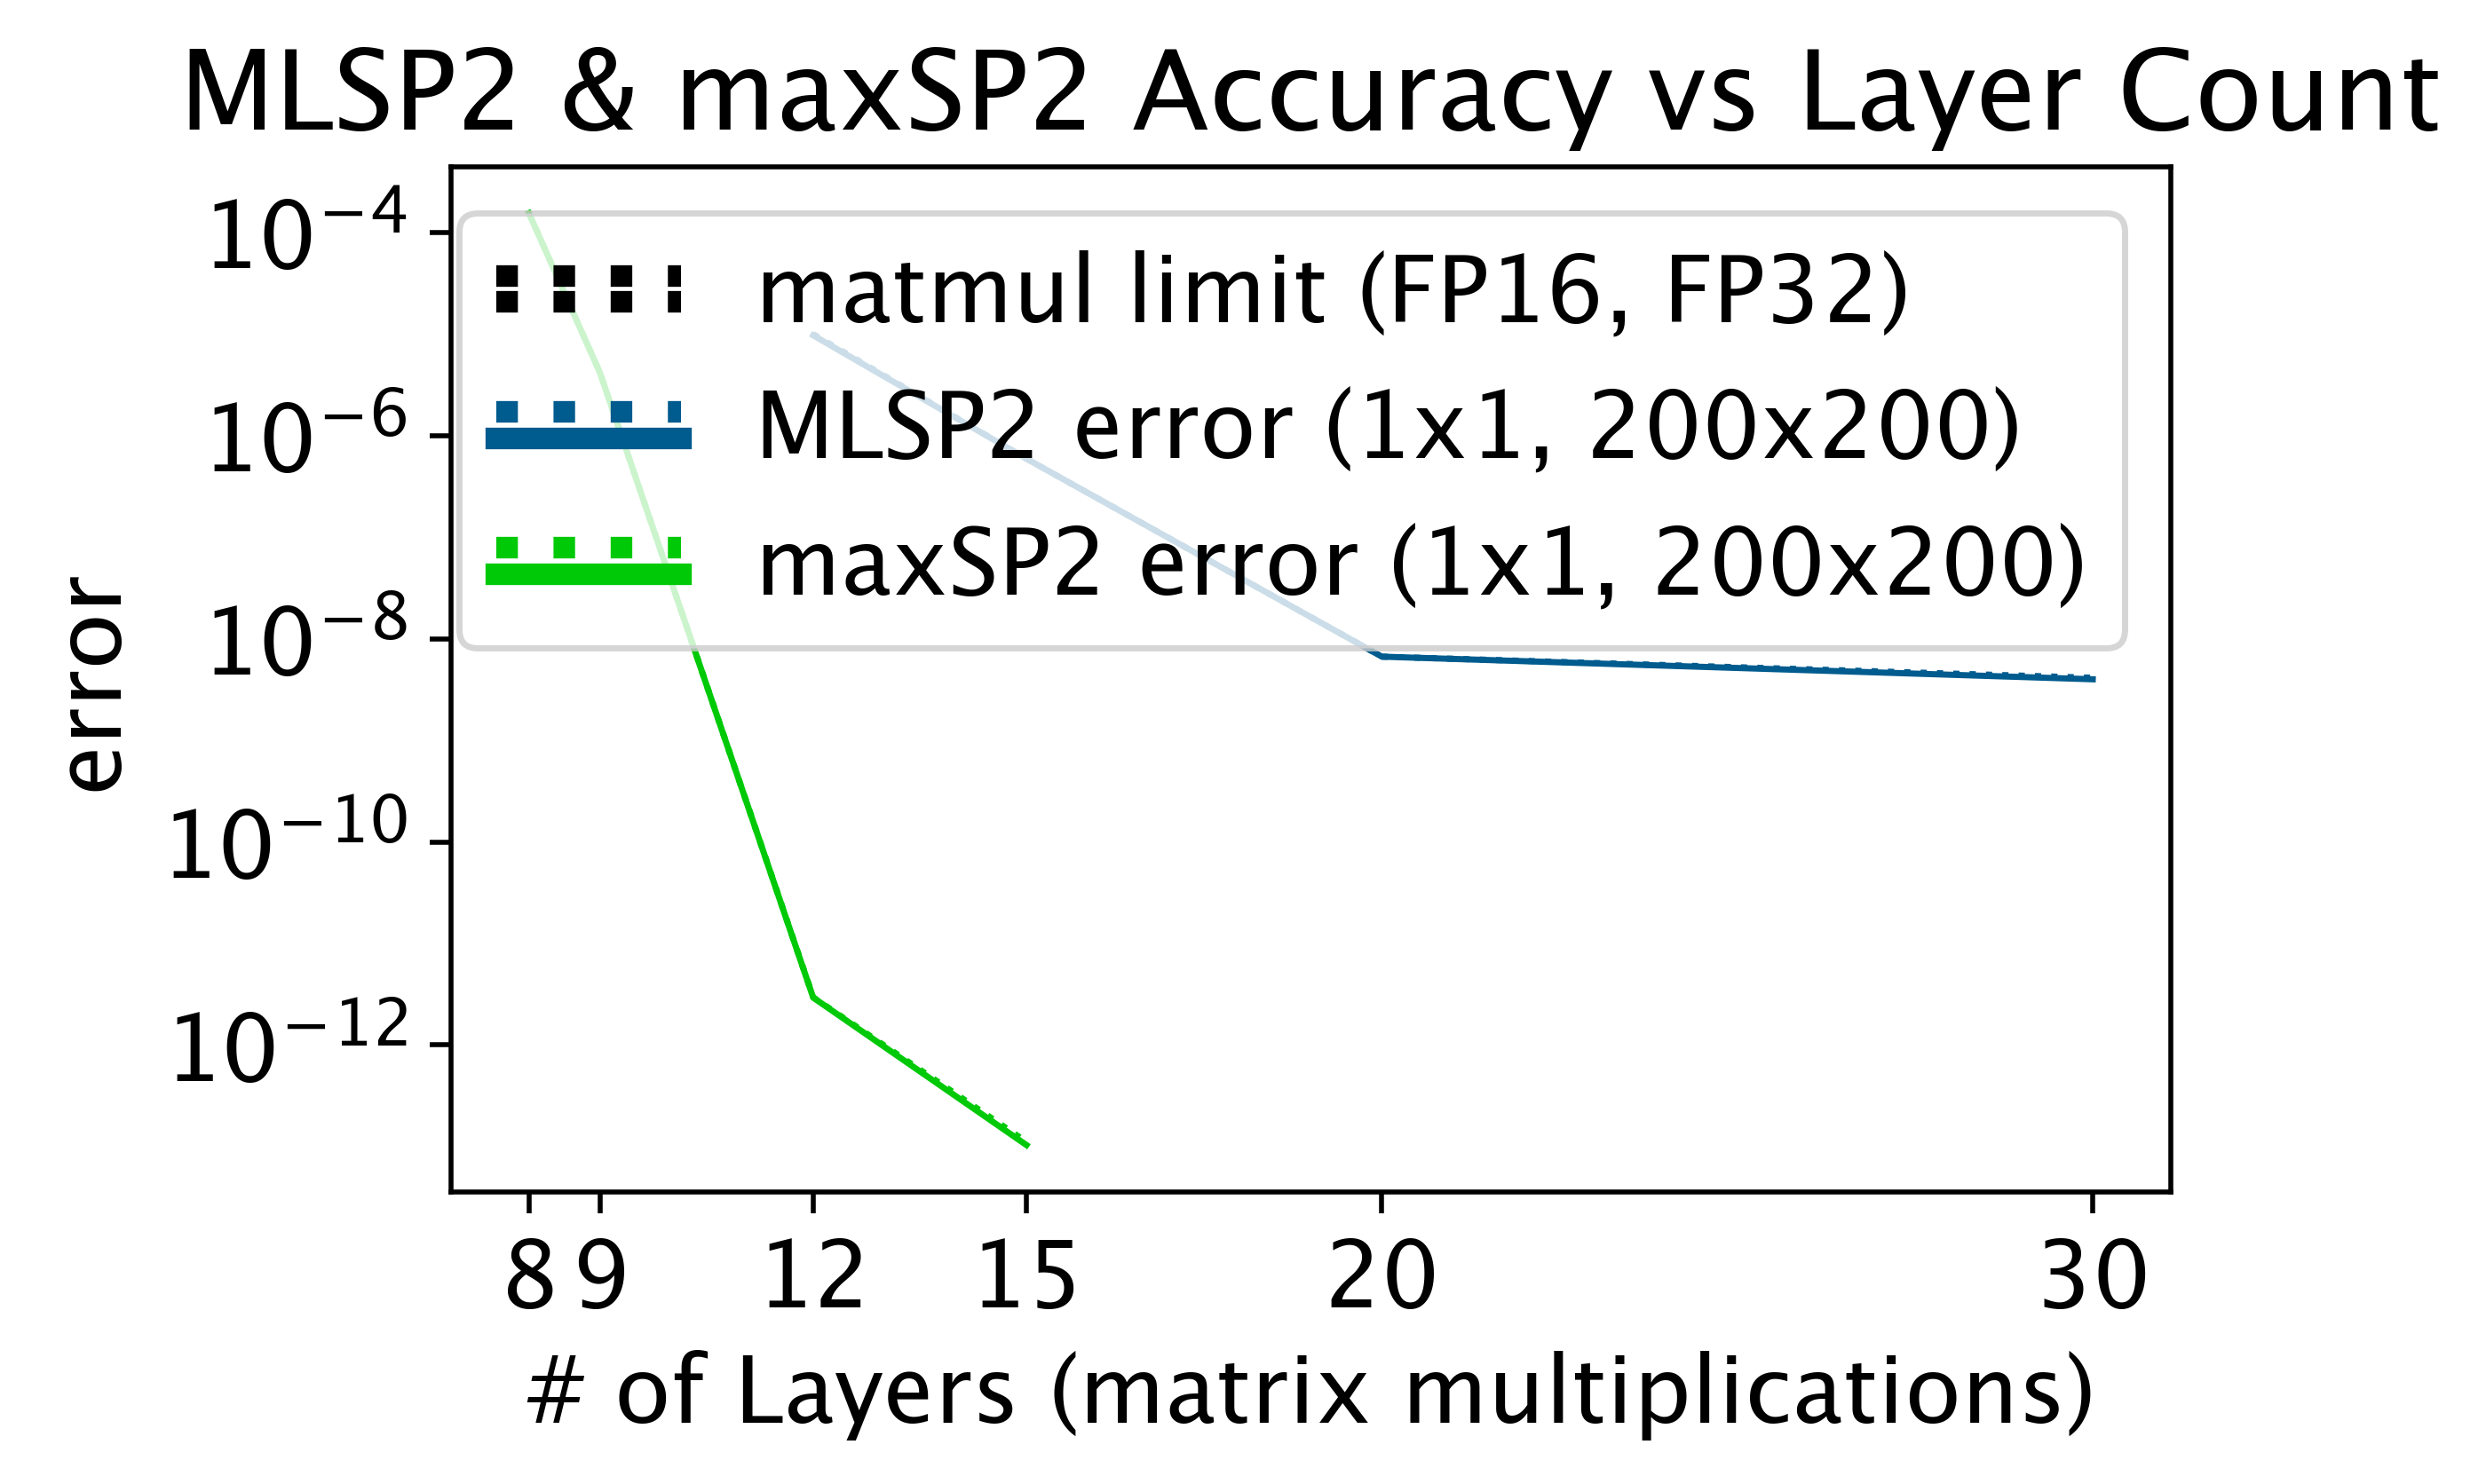

In [ ]:
N1 = 100
N2 = 100

max_15 = [-1.0154343996848036, 1.085331450921506, -0.009883158584843583, 0.10062486493601777, -1.0702316770604083, 1.0139500382040014, 0.004105850457017903, -0.016850294359264974, -1.115920346348479, -0.9849979113561063, 0.010918067198416698, 0.008545052127609663, 0.027847897011584005, 1.1072770208733762, 1.0050155745208604, 0.06448074942760708, -0.0035814152770917347, -0.26639732132089156, -0.02269126099896113, -0.9995058028906988, 0.008849112115959665, 0.16776841352012295, 0.0005113576573814169, -0.016949571908525092, 0.07526872779275919, 0.054472396042252694, 0.9950540564897078, -1.0033508782577014, -0.045073704983252756, 0.004906494828308319, 0.036337234497935966, -0.060650707719357023, 0.04901555429894634, 0.013061185484634927, 0.8719796466356227, -0.012626023633452145, 0.15886067381292637, -0.06084240758361443, -0.051295291787940164, 0.16865766385329922, -0.04114942796520826, 0.13175606620440825, -0.10005874773671806, -0.9970753391330841, 0.971838952472957, -0.11193076550967797, -0.038045660643675414, -0.27703950236717506, 0.004541435192956481, -0.4842667479923377, 0.25933416342408583, -0.20946428621713883, 0.025493459035790172, -0.9723512687744896, -0.946074889056961, 0.30420402093825794, 0.06186659441914483, -0.0844081679298918, -0.006897587564344501, 0.20316530491012377, 0.520201635461208, 0.21979842819678425, -0.05283446532123845, 0.25244719235169677, 0.8404619919103924, 0.9373045452846743, 0.004167408977406391, -0.25002802901703647, -0.018078473399977046, -0.0010667421335301766, 0.01328571994401634, -0.04882658213312637, -0.1229060478014186, -0.18866382231007955, -0.24312477744077934, -0.10242205062176588, -0.47785290320363166, -0.09351705979888109, -0.01374280786530908, -0.11854741818439167, -0.14449779804059112, -0.06949575734167358, -0.40420229733017654, 0.18397898697896883, -0.10008946109965093, -0.32157578008133475, 0.3866969910774815, -0.05254317029881476, 0.37462331085884054, 0.8034118690812646, -0.967001193300216, 0.11816618258080624, 0.11014994480758795, 0.050050752906659016, 0.03974702268729477, 0.049647635041802515, -0.04903663788270729, 0.037300885710894606, 0.08987362345822361, 0.08090037144551916, 0.015802506503897872, 0.10391900813836281, -0.10143046051236992, 0.7352613408192272, 0.9808115159849682, 9.45492263584187e-6, 0.02412139492516765, 0.09015995332525967, -0.0017380586000822823, 0.156140140351595, 0.02617908847590363, -0.1617958023384313, 0.14908008094142056, 0.016265207886379224, -0.14157907108630455, -0.06033570343033657, -0.1642852646555703, -0.4671760339725797, -0.8454768672693588, -0.979812849319639, 0.07414165226848272, 0.012836519549994383, 0.10149923763704882, 0.060990648248543555, 0.10093751628306158, 0.04748416936125476, 0.06627261882157914, -0.05478458702542143, 0.05286255712216693, 0.00545621583516601, 0.07765846138560033, -0.08589920789550852, -0.19737113921891306, 0.057379635484807665, 0.9015922540093286, 0.9364534340748699, -0.21282424336151562, -0.1279994372597599, 0.12293019350347524, -0.023193381500843966, 0.10127830308772644, 0.007896127005798262, -0.1757450741323806, 0.03383140823198948, 0.1342607500993279, -0.1264822314995159, 0.056885870169926744, -0.009400786772431535, -0.036367872088206174, -0.06177451530721089, -0.07735751544304166]
max_12 = [-1.5157814637610016, 3.111222027820314, -1.343467114263754, 2.885295904061351, -0.014665930792336959, -0.1696121391617671, 1.6636291282880122, 3.8448773126134697, -4.855346338316492, -0.6491705203224799, 0.3965569798996214, -0.8029993972990777, 1.0344441899580554, 2.0737812263978417, 0.44723713393956116, 1.092495914621839, 2.76859049671161, -3.341179576669994, -0.6830921201819294, -1.8138497968279714, -0.1585331141597489, -1.087585749926677, -2.8811384204386434, 3.130648085168252, 1.7163138177492983, 1.4068184674595057, 1.4702260152961855, -0.35024475809343114, -0.07058382957307589, -2.9094012920731496, 3.59265588142426, 0.18064388035638584, 0.17807441637644963, -0.23615870970447586, 0.8683884159512135, -0.7270975301443876, 0.7655118029805952, -0.2066873735544048, 0.17447214601006097, 0.5681766127101253, 0.16730311009024568, 0.4571239591687129, -0.38928789037608075, -2.014374527314977, 0.5751871543919101, 0.955011039368022, 0.15340654710028168, -0.39295244143485747, -0.15531720521878908, -0.031271975635254606, -0.003479307905915107, 0.23781364569083033, 1.949325340003712, -0.7614015513182985, -0.6633347037804347, 0.29383051826076373, 1.8064115657990238, -2.1773668432902578, 0.0590646076850494, 0.0032298222027336665, 0.29905300808404434, -0.4492772879421647, -2.346500321825239, 0.7733225662822905, 0.6499540695487354, 0.8730550449732277, -0.06534601430883706, 0.0038282725789689303, -0.06774408065745231, 0.029630159358547188, -0.117941714656349, -0.1982343836490418, 0.22113304278469864, -0.9422232429560197, 0.32211632453399974, -0.07508396231424894, -3.1729365862999974, -0.446668716476862, 0.46576245550868517, 0.11506190370207856, -0.00962561992506847, 0.8768776458994493, 0.2696352015517041, 1.0848008241107538, -0.8208843887997022, 1.5331274222571765, -0.8433971461735276, -0.10775626549950448, -0.3869756632702804, 1.1670625532833157, 0.1460066622597547, 1.6008922105093575, 4.6371393083879955, -5.138602365811533, 0.40832044443973203, -0.1325592092987263, 0.08060639271281259, 0.13743246554564992, 0.04104159793369637, 0.09633387634343848, -0.5646338181781423, -1.2430192396798407, -0.11412020929393163]
max_9  = [-0.9544360959733179, 2.6129123361690687, -0.5736115025070653, 2.8760979395450486, -0.20823182534469492, 1.5465060016159398, -2.1164252110973116, -0.1930371290026151, -0.14853743113909113, -1.3943206839346587, -1.7913544553040122, -4.775461844515223, 3.698643723304795, 2.1957122673474916, 1.39269944781505, 1.3230025042640785, 3.756163936169002, -3.1690052363289474, -1.7787702136574373, -72.45731126138257, 1.5059107769354596, 0.13081143912869359, 3.0939752270779515, -2.305960777118972, -1.828840284407347, 17.227467788063095, 2.6223632064162934, 0.5630417286345538, 1.7331629014004286, 3.675715643664045, -2.624447798564791, -1.5269828592649044, 2.6194916183883614, -2.8165066232927285, 31.496739120376205, 1.3215640549265348, 2.7818675159032957, 5.919968419627444, -4.5598562600670265, -2.7098283928740052, 4.236268006501049, -1.176306453282483, 1.5131746285175585, -3.2197209934263156, 7.367403575361106, -5.450495956475263, 7.783468989692422, -5.740703453723038, -6.066253065661424, 34.06029688953311, 19.63353056052893, -10.037897365664437, 15.665875683785575, -6.771213043367818, -5.581593490477135, -14.982261859916672, -27.741462963784446, 21.27145038190072, 12.470832562521835, 27.56862269593943, 7.007770093797541, 32.5226027025473, 24.25469661606773, -7.286049226566891]
max_8  = [-1.1533677014913988, 2.2605661812191777, -0.9635333037964505, 2.6220176535216044, -0.1827392350660419, -0.041149393727695, 3.3492111297683853, 1.917493198819509, -2.6431830442560753, -0.9848087554653816, 1.8807529372134268, -0.0654661376565956, -0.20556738891580956, 0.46245526975754486, 1.2565063553477576, -1.022350263285046, 0.11931211247264827, -0.29059640434441203, 0.13873034615535113, -1.0421402946680456, 0.535846480808057, -0.30696723225241246, -2.230000845836373, 0.4604911264926313, -0.4933918110529396, 1.4291970561185774, 1.6151616377615579, -0.2165374209386636, 0.4613613128602122, -2.211857641568498, 1.6785802073883431, -0.08042285915255848, 0.062373968491741295, -0.1621559527842398, 0.22322182802881207, 1.2759833904345959, 2.9323704483448005, 1.6034718963391805, 1.0287637747474867, -1.0618533578856721, -1.348098454597992, 1.4216219397543477, -1.4851853717790964, -4.16870192284362, 1.1336892784912205, -1.4462542287051356, 0.36837717389437097, -0.36831288262009665, -0.15394770498345783, -0.22870345324117242, -0.08196935965295558, 0.10534173463679691, 0.3717408100857815]

sp2_30 = [-1.0963584681715322, 2.0895550133913954, 0.000783657084099098, 3.2523960758137046e-8, -1.0820987096236212, 2.009431786332212, 0.00457369574971024, -5.901257682497126e-8, 1.0308777003729037, -0.001444262999756863, 0.019332191268658337, 1.5069957978807723e-5, -1.0875936001299713, 1.995702619724334, -0.0031448602570911728, -6.9830133206502155e-6, 1.007189422544783, -0.008783488815705344, 0.021417118039926214, 7.238675850131462e-6, 1.0013086191791836, 0.04540945509289195, -0.0020829872852974165, -0.0006333952523476468, -1.2273792761014757, 1.973422907815507, 0.008964802643713611, 0.0007877933776792841, -0.9928494762250495, 1.979050845719563, -0.006357775299858692, 1.1157058591254767, 0.902650327183397, -0.00981251452675333, 0.23460238924136165, -0.5625190996263553, -0.9898533504874628, 2.0086583010466077, 0.010762607470758434, -1.1172856619870342, 1.0135552706718436, 0.0213902292734566, 0.023817140949010464, 0.4891478658655215, 1.0267573515443076, 0.04923212321908852, -0.009833681152236751, 0.08769559079792986, 0.10380296235253797, 1.0206082123550262, -0.016628843643875704, -0.31933025146641136, 0.061783409998331956, 1.0286137072611705, -0.029122408482340507, 0.33951871455679666, 0.0700273299514748, 1.0342760799098563, -0.05235981548367955, 0.24362590502315307, 0.0724200903903667, 1.0463422440398402, -0.09498321189067278, -0.06979643414620137, 0.06623185814887324, 1.059495519635897, -0.16971099424819228, -0.20119703395033095, 0.1486206885987821, 1.0394859005567576, -0.29384599288358393, -0.05186277131715073, 0.2100357358371099, 0.9758007586816507, -0.4309359275234475, 0.12241262485569854, 0.2330732939222703, 0.8783006289128962, -0.437247915108482, 0.14397605853268597, -0.008858053570602457, 1.0452221294727315, -0.44481383249678325, 0.12071515944526261, 0.337643374555154, 0.5151726632324983, -0.42029753047678764, -0.08331397407272094, 0.35726196072346894, 0.36349705690617734, -0.14734791437839143, -0.009277794518122136, 0.2058373346959922, 0.6372571721215946, -0.04425015625696371, -4.136002194201675e-5, 0.0001496909546279526, 0.7339763184410135, -0.026279155807005718, -1.0748605607008734e-7, 6.406385034550452e-11, 0.8702471923567632, -0.0123905332729467, -0.08590481341577004, 1.3080892620056775e-10, 0.8566175730429116, 0.00668556943663483, -0.1237816852768002, -1.2341915096203253e-9, 0.8611154591415169, 0.02871346572216307, -0.13786182987918189, -1.0569643449108395e-9, 0.8566381014026727, 0.06764344113757007, -0.14642863186128194, 1.963619632171175e-9, 0.8549651289042756, 0.12803755012955997, -0.14503487109572408]
sp2_20 = [-0.9578185977334848, 2.0495579313001997, -0.002448848378338114, 1.2146821575469446e-6, -1.0398663560712549, 2.0014621717193104, 0.0049175027385917735, -1.7690172557226302e-6, 1.0069440404170273, -0.011044375526572048, 0.02362552782472742, 1.8878127198045575e-5, -1.0554063770278515, 2.000672889304727, -0.008643892025391954, -7.521641777872676e-6, 0.9966413636660806, -0.023067232810681286, 0.02382626212208848, 1.111404847542702e-5, 0.9800032535193671, 0.03688325304591692, -0.06679631302892901, -0.0010223479238070708, -1.2363178136767412, 1.8888427576868605, -0.04588250014319624, 0.0005328060019440851, -0.8501022201079761, 1.8518450902613108, 0.46063035471657976, 3.0299784031756225, 0.42805378248943887, -0.10103003799418576, 0.48435759610749485, -1.4058651801344546, -0.9384847512467621, 2.0583638422693955, 0.054255441247867235, -2.7556255338921933, 1.0870179656356607, 0.15719905391442215, 0.24068555372109318, 6.055455396813611, 1.0854788061562612, 0.30464054431972953, -0.6287555658703832, -6.156600494980335, 0.23310173980756924, 1.0263714320373052, -1.1585761338741813, 2.5636342300216417, 0.5241496542920665, -0.512621373255027, -0.613005381612433, -0.6757985933411895, 0.07581181387272372, 0.9902520734894018, -1.5398704846031266, 0.07363655710316594, 0.002561843807335157, 0.7310855451854342, -0.6177482143462271, 0.7401866870153895, -0.00016809741663111386, 0.08721255602510512, -3.299489280391601, -0.7189424265639284, 1.2825787089377951, -1.5063206624103513, -0.33640808053596233, -0.16685569535312242, 0.001254508162099076, 0.8442498445592626, -1.387640270985386, -0.12822405040822138, 0.00020796239092655768, 0.7354903096271933, -4.416648093751473, -0.26450969037280986]
sp2_15 = [-1.3206907634991196, 2.2541198492562913, -0.03321365301196344, -1.3347686428616045e-7, -1.1926763771399744, 2.0620136026586535, -0.008177377502903585, 5.796172012731717e-7, 1.1372214175639346, -0.017595377954572645, -0.010684266071537354, 5.1239702568031606e-5, -1.1825902987675723, 2.01701231638176, -0.0016241876783014782, -6.629148109109778e-6, 1.0742793146863219, -0.0049839755170347395, 0.004030237738636868, 0.00026977694620551135, 1.1470187171594044, 0.0034319624541438885, -0.002685187495598121, 0.002378423307019412, -1.2760944612500316, 2.0162373838890346, 0.0013014908972884443, -0.0006346358741622109, -1.0261249098567362, 2.0086029673454826, 0.027668248231693067, -0.5153753065824601, 1.0577846766495773, 0.030577479480607832, -0.008412258204579366, 0.25967674449452205, -1.0061777897306277, 1.9972044584062971, -0.010758948335979238, 0.9121446090648843, 1.0079239087418819, -0.016473952510892884, 0.05545233772263396, -0.38049155615226304, 1.0249556240893403, 0.15802053966672963, -0.31295183332908794, -0.023458458307494677, 0.7076456819479038, 0.6087732837002658, -0.1959765402631409, 0.07418480920563254, 0.5311516325697404, 0.5504769894155115, -0.04001804069241269, 0.17077921625107162, 0.060927262023164605, 0.636651130260584, 0.10964970624834484, -0.36334886973916763]
sp2_12 = [-0.9456076153209758, 2.1224755090931846, -0.04922778668288888, 0.00046857925800457853, -1.1098926325077207, 2.024805014892416, -0.027600386485605578, -0.000522034272402432, 1.062461429427403, -0.05081628632050881, -0.007662804765964852, 0.00035132471989872665, -1.2864498850149706, 1.9485407960993817, -0.02072931087543767, 0.0003551037870246637, 0.9785921807439835, -0.0406324568560149, -0.00721958593465488, 0.002229988630668418, 0.9604502225081383, -0.0028699841151892088, -0.021124561169703227, 0.044030157745948865, -2.421885526099491, 0.9169864437344795, -0.049862852935672074, -0.05709443640891107, -11.050860582699409, 1.1604953232245188, 0.14519195875339092, -1.6669141232514142, 14.422102400228072, -0.3214765240687308, 0.10925141941838964, 1.1819127149314004, -2.2239644720356515, 1.934991592473725, -0.17289363438855535, 1.9168491777785874, 3.1905982418858443, -0.07439924532259874, 0.08311625659695993, -0.43383383927210156, 4.379768385412945, 0.29944194585928796, -0.4102494585236265, 0.2994419458593832]

max_L = [ 8,  9, 12, 15]
sp2_L = [12, 15, 20, 30]

beta_new, mu_new = 54, 0.25

sp2_12 = reshape_W(sp2_12)
sp2_15 = reshape_W(sp2_15)
sp2_20 = reshape_W(sp2_20)
sp2_30 = reshape_W(sp2_30)

def _MaxSP2(x,theta,d_, s):
    y   = [1,x]
    for t in theta:
        y.append( sum( th * y_ for th, y_ in zip(t,y) ) ** 2)

    return sum( D * Y for D,Y in zip(d_,y) ) + s * y[-1]

_MaxSP2 = jax.vmap(_MaxSP2, (0,None,None,None))

def MaxSP2(x,theta,d_, s=-1):
    return _MaxSP2(x, theta, d_, s)


def MaxSP2_m(x,theta,d_, s=1):
    I = jnp.eye(x.shape[0])
    y   = [I,x]
    for t in theta:
        y_ = sum( th * y_ for th, y_ in zip(t,y) ) 
        y.append( y_ @ y_ )

    return sum( D * Y for D,Y in zip(d_,y) ) + s * y[-1]

def recover(theta_vec, n):
    theta = np.zeros((n, n+1))

    for i in range(1,n+2):
        for j in range(0,i):
            theta[i-2,j] = theta_vec[ ( i * (i - 1) ) // 2 + j - 1 ]

    d_index = (n * (n + 1)) // 2 + n

    d_ = theta_vec[d_index:]

    return (theta, d_)


X       = sample_dist(key, N1, N2)[0]
y       = target(X)

key, subkey = jax.random.split(key)

N_mat = N1+N2

H = jax.random.normal(key, (N_mat, N_mat)) + 1j * jax.random.normal(subkey, (N_mat, N_mat))
H = H + H.conj().T

spectrum, U = jnp.linalg.eigh(H)

assert jnp.allclose(H, U * spectrum @ U.conj().T)

Y = 1/(1 + jnp.exp(beta_new * (X - mu_new)))

H = U * X @ U.conj().T
D = U * Y @ U.conj().T  # exact solution

err_mlsp2_scalar, err_mlsp2_linear = [], []

for sp2 in [sp2_12, sp2_15, sp2_20, sp2_30]:

    err_mlsp2_scalar.append( jnp.max( modelj(X, sp2) - Y ) )
    err_mlsp2_linear.append( jnp.linalg.norm( mlsp2j(H, sp2) - D, ord=2 ) )



err_maxsp2_scalar, err_maxsp2_linear = [], []

for mx, n, s in zip( [max_8, max_9, max_12, max_15], max_L, [-1,-1,-1,-1] ):

    theta, d_ = recover(mx, n)

    err_maxsp2_scalar.append( jnp.max( MaxSP2(X, theta, d_, s) - Y ) )
    err_maxsp2_linear.append( jnp.linalg.norm( MaxSP2_m(H, theta, d_, s) - D, ord=2 ) )



plot = plt.semilogy

plt.rcParams['lines.linewidth'] = 3.5

plt.figure(figsize=(5,3), dpi=500)

ticks = list(set(sp2_L + max_L))

plt.xticks(ticks)

#plt.axhline(y = 1e-3, color='k', linestyle='--', label='FP16, FP32 matmul limit')
#plt.axhline(y = 1e-6, color='k', linestyle='--')

lw = 1

plot( sp2_L, err_mlsp2_scalar, c=colors[1],   label='MLSP2 error (scalar)', lw=lw)
plot( sp2_L, err_mlsp2_linear, ':', c=colors[1], lw=lw) #, label='MLSP2 error (spectral)' )

plot( max_L, err_maxsp2_scalar, c=colors[3],   label='maxSP2 error (scalar)', lw=lw)
plot( max_L, err_maxsp2_linear, c=colors[3], linestyle=':', lw=lw) #, label='maxSP2 error (spectral)' )

plt.title('MLSP2 & maxSP2 Accuracy vs Layer Count')
plt.xlabel('# of Layers (matrix multiplications)')
plt.ylabel('error')

from matplotlib.legend_handler import HandlerBase

class AnyObjectHandler(HandlerBase):
    def create_artists(self, legend, orig_handle,
                       x0, y0, width, height, fontsize, trans):
        l1 = plt.Line2D([x0,y0+width], [0.7*height,0.7*height],
                           linestyle=orig_handle[1], color=orig_handle[0])
        l2 = plt.Line2D([x0,y0+width], [0.3*height,0.3*height], 
                           linestyle=':' if orig_handle[0] == 'k' else '-', color=orig_handle[0])
        return [l1, l2]
    

plt.legend([("k",":"), (colors[1],":"), (colors[3], ":")], 
           ['matmul limit (FP16, FP32)', f'MLSP2 error (1x1, {N_mat}x{N_mat})', f'maxSP2 error (1x1, {N_mat}x{N_mat})'],
           handler_map={tuple: AnyObjectHandler()}, loc='upper right')


plt.savefig(fig_path + 'accuracy vs layers.pdf', bbox_inches='tight')

## Entropy Accuracy

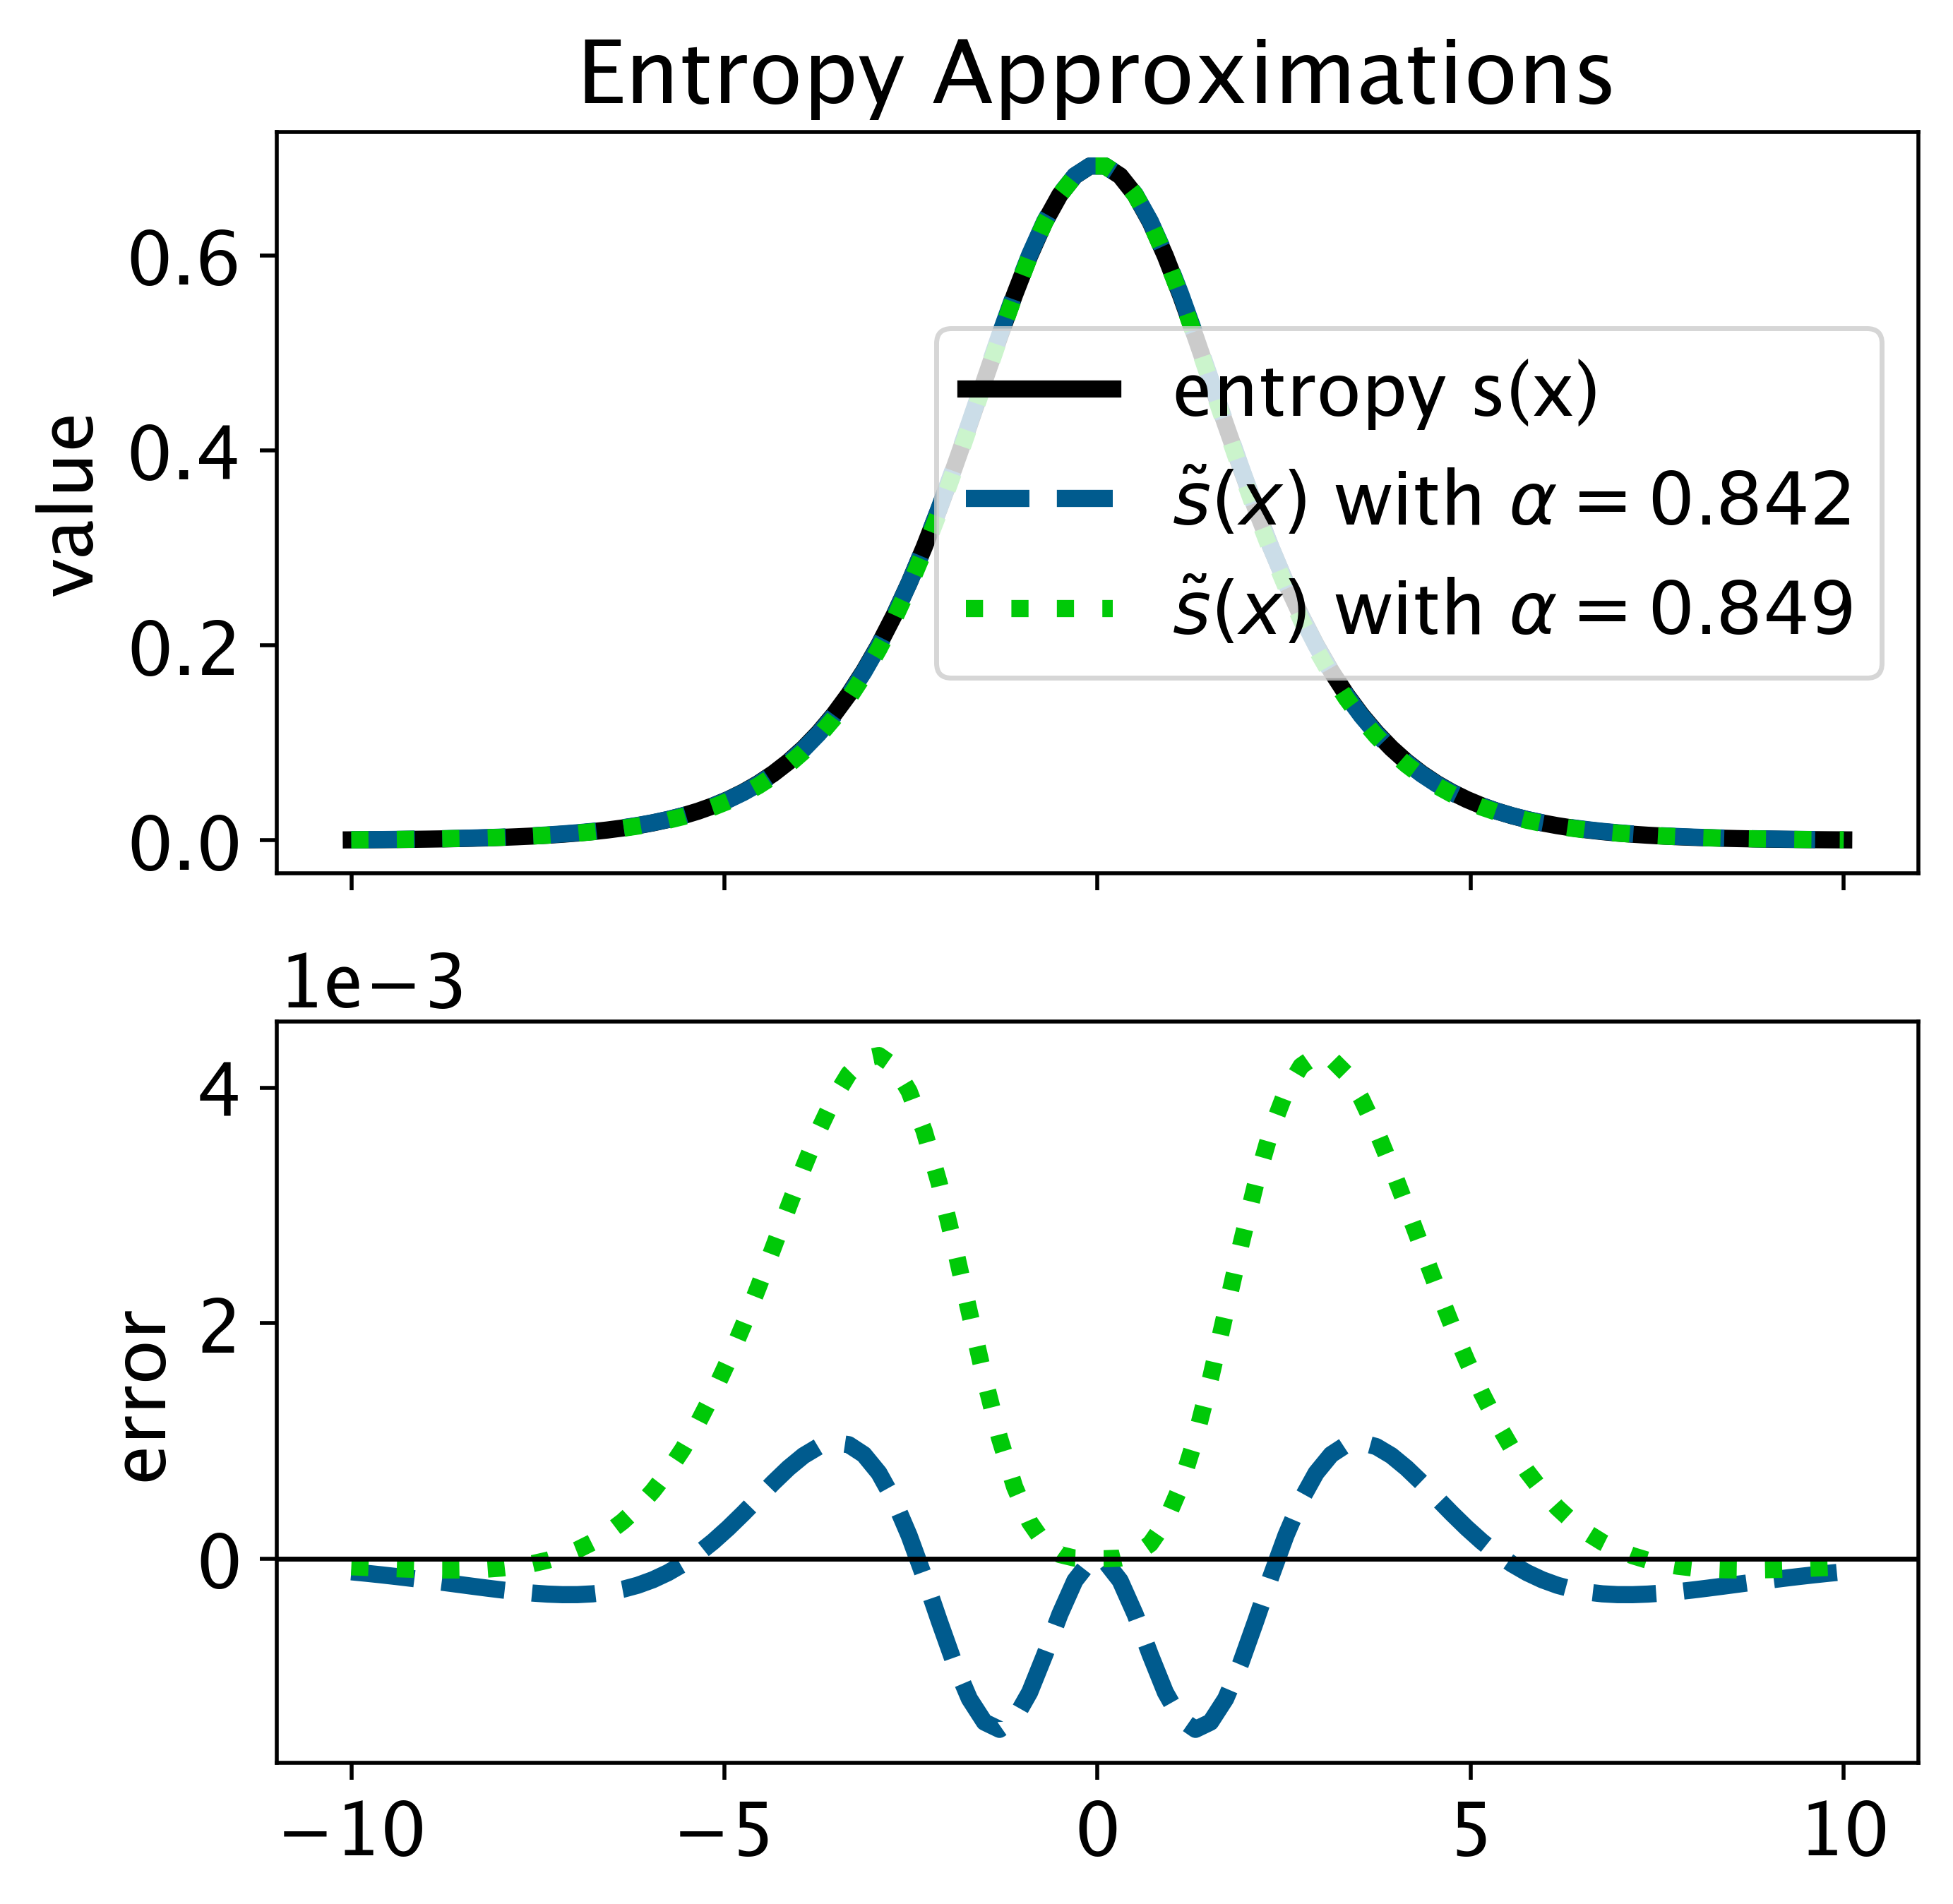

In [ ]:
x = np.linspace(-10,10,100)

alpha  = 0.842095
alpha0 = 1/np.sqrt(2 * np.log(2))

f = lambda x : (1 - np.tanh(x/2))/2
S = lambda x : -x * np.log(x) - (1-x) * np.log(1-x)

s  = S(f(x))
s1 = 4 * np.log(2) * f(alpha  * x) * (1 - f(alpha  * x))
s2 = 4 * np.log(2) * f(alpha0 * x) * (1 - f(alpha0 * x))

fig, (ax1, ax2) = plt.subplots(nrows=2, ncols=1, figsize=(6, 6), dpi=500, sharex=True)

ax1.plot(x, s,  'k',   label='entropy s(x)')
ax1.plot(x, s1, '--', label=f'$\\tilde s(x)$ with $\\alpha = {alpha:.3f}$')
ax1.plot(x, s2, ':', label=f'$\\tilde s(x)$ with $\\alpha = {alpha0:.3f}$')
ax1.set_title('Entropy Approximations')
ax1.tick_params('x', labelbottom=False)
ax1.set_ylabel('value')
ax1.legend()#loc='upper center', bbox_to_anchor=(0.5, -0.1))

ax2.plot(x, s-s1, '--') #, label=f'error for $\\alpha = {alpha:.6f}$')
ax2.plot(x, s-s2, ':') #, label=f'error for $\\alpha = {alpha0:.6f}$')# + r'$= \frac{1}{\sqrt{2 \ln 2}}$')
ax2.axhline(0, color='k', linewidth=1)
ax2.set_xticks([-10,-5,0,5,10])
#ax2.set_title('Error')
ax2.set_ylabel('error')
plt.ticklabel_format(axis='y', style='sci', scilimits=(0,0))
#ax2.legend() #loc='upper center', bbox_to_anchor=(0.5, -0.1))

plt.savefig(fig_path + 'entropy accuracy.pdf', bbox_inches='tight')

In [ ]:
t_fake = np.arange( len(max_12) ) + 1

t_fake, d_fake = recover(t_fake, 12)

t_fake, d_fake

(array([[ 1.,  2.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.],
        [ 3.,  4.,  5.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.],
        [ 6.,  7.,  8.,  9.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.],
        [10., 11., 12., 13., 14.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.],
        [15., 16., 17., 18., 19., 20.,  0.,  0.,  0.,  0.,  0.,  0.,  0.],
        [21., 22., 23., 24., 25., 26., 27.,  0.,  0.,  0.,  0.,  0.,  0.],
        [28., 29., 30., 31., 32., 33., 34., 35.,  0.,  0.,  0.,  0.,  0.],
        [36., 37., 38., 39., 40., 41., 42., 43., 44.,  0.,  0.,  0.,  0.],
        [45., 46., 47., 48., 49., 50., 51., 52., 53., 54.,  0.,  0.,  0.],
        [55., 56., 57., 58., 59., 60., 61., 62., 63., 64., 65.,  0.,  0.],
        [66., 67., 68., 69., 70., 71., 72., 73., 74., 75., 76., 77.,  0.],
        [78., 79., 80., 81., 82., 83., 84., 85., 86., 87., 88., 89., 90.]]),
 array([ 91,  92,  93,  94,  95,  96,  97,  98,  99, 100, 101, 102, 103]))

In [ ]:
def fix_bands(theta, l=3):
    n = len(theta)

    for i in range(n):
        for j in range(1, i+1-l):
            theta[i,j] = theta[j+1,j] #* theta[i,i-l]

    return theta

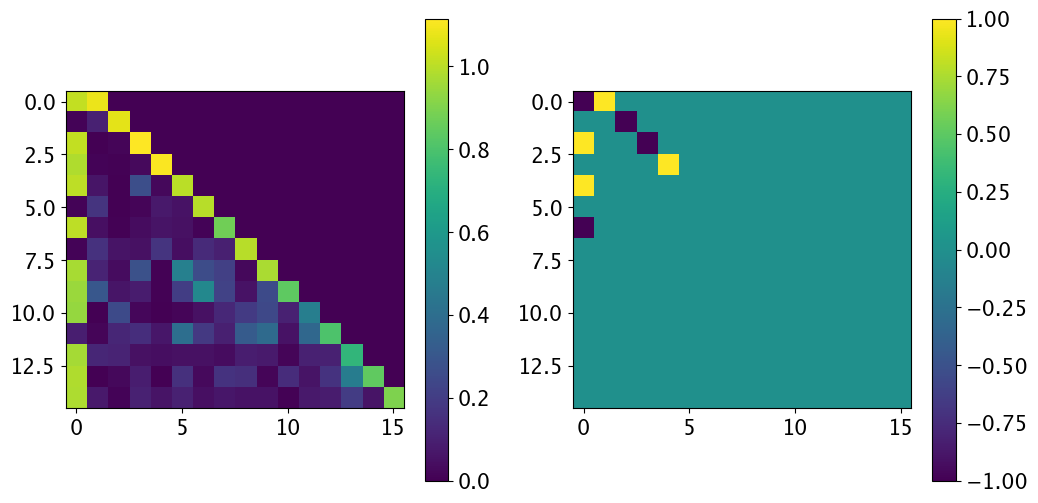

In [ ]:
new_15 = [-1.0042171616214437, 1.3389860872609913, 0.00812495715775574, 0.18431219027493334, -1.0950513231371621, 0.9926622405480899, -0.09319379462881999, 0.011803082893384147, -1.1744354091960425, -1.0118079348168247, 0.031996573544190596, -0.016122160726613318, -0.05843250549097854, 1.042506928453389, 0.9967404657229166, -0.09695191361166822, -0.005106163139126486, -0.0815859409894288, -0.004830691633769201, -1.121618300208514, -0.010989715752517604, 0.08590176012662246, -0.0673531787117188, -0.17482785764219047, 0.02922045671004036, -0.03760118580350648, 1.0168084679994933, -1.0185734158426818, 0.006324366425297104, -0.012906463224097298, 0.27064800929343025, -0.03729842520031848, 0.09215951007452665, 0.005848504520565087, 0.9626168237492676, -0.019606794967245388, 0.6310619364948703, -0.19341114668872428, 0.02755223969247954, 0.18211794130027678, -0.2590226885324427, 0.006796344975898318, -0.05943793514611033, -1.0370711335791007, 1.0038923443453869, -0.05780045011659126, 0.05671477859819103, 0.023571780592578577, -0.020338774405455798, -0.35084174478632124, 0.06164859663895197, -0.10745141999539842, -0.14239293847527032, -0.7183724694426747, -0.9343876258400728, -0.09958710199766993, 0.1371452767807852, 0.03769209106389667, -0.16436318779703954, 0.003935568260808939, 0.23908100086967443, -0.49811299382941576, -0.20842785462741972, 0.8559994197547254, 0.9200580399367585, 0.9826582186962944, 0.19556372169499472, -0.13075247074430774, -0.1786372166389065, 0.05148906698432232, -0.1345739869051502, 0.08609914114999016, 0.10476017304438286, -0.025639157451498383, -0.6349477355080685, -0.1309339088095127, -0.7658149043889493, 0.02786281515254301, 0.018447118440208035, -0.010324932578346789, -0.005110029233665971, -0.02353910717191403, -0.13634282797898412, -0.021320121758009316, 0.09497144431702038, -0.055661623177615985, -0.13516563275658852, -0.2106542410685269, 0.3628466497245991, 0.9043018317693712, -0.9606828163182227, 0.21658829607099978, 0.020972910334151468, 0.04316222709184623, 0.1172536763433271, 0.0025604137010423957, 0.043432172789803394, -0.2512982438474911, 0.03538718033621167, 0.05674064295364406, 0.027825402120517078, 0.035377142191959386, -0.01575072383499706, 0.7158079524588348, 1.002480698941562, 0.08283175405267146, -0.11630344331543475, -0.011631917496160169, 0.06407794921208504, 0.0018774622340204175, 0.0706860601229759, 0.2312059034440242, -0.08431643550012068, -0.03829552410125739, 0.17953919168877058, 0.04003539288553429, -0.0434153294956391, -0.37371759446287206, -0.8703608499433622, -1.0317337375688358, -0.04069582577505454, -0.05179440391816771, 0.04772160906310018, -0.04504457246921296, 0.0009128091465885775, -0.09712294972862033, 0.20400273287010778, -0.040905142633993974, 0.008229987836543301, -0.21380892305997842, -0.01086335318489964, 0.4794645558827094, 0.09260606349515454, -0.031938239377444555, 0.8172908264912399, 1.000000000000166, 3.914628339263511e-14, 5.900788027025964e-13, -6.310576162129147e-13, -4.3277466728737646e-14, 5.577869455716492e-13, 1.0587888229456303e-13, 1.766851901903275e-13, 2.5705831693496223e-13, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]

theta, d_ = recover(max_15, 15)
theta_n, d_ = recover(max_15, 15)

plt.figure(figsize=(12,6))

plt.subplot(1,2,1)

plt.imshow(jnp.abs(theta), cmap=CMAP)
plt.colorbar()

plt.subplot(1,2,2)
plt.imshow(jnp.asarray(theta, dtype=int), cmap=CMAP)
plt.colorbar()